# 백혈구(WBC) 현미경 이미지 4클래스 분류 — 전 과정

**2조 프로젝트** / 데이터: Kaggle `paultimothymooney/blood-cells`
교재: **딥러닝의 정석 with 파이토치** (수업 1~5장)

이 노트북 하나로 **데이터 확인 → 전처리 → 모델 → 학습(에폭) → 최적화 → 평가 → CAM → 가설검정 → 결론**
까지 전부 돌아간다. 외부 모듈 없이 **이 파일 하나로 완결**된다.

---

## 수업에서 배운 것을 어디에 썼나

| 수업 | 배운 내용 | 이 노트북 |
|---|---|---|
| 1장 | `device` 확인, GPU 시간 측정에 `torch.cuda.synchronize()` | §1, §8 속도 측정 |
| 2-1 | 시드 고정으로 재현성 확보 | §1 |
| 2-3 | `nn.Module` 로 모델 만들기 (`__init__` / `forward`) | §6 |
| 2-4 | `Dataset` / `DataLoader` | §5 |
| **2-5** | **학습 루프 다섯 줄** — `zero_grad → forward → loss → backward → step` | **§7** |
| 2-6 | `state_dict` 만 저장 | §7 체크포인트 |
| 2-8 | `model.eval()` + `torch.no_grad()`, 혼동행렬, ROC/AUC | §7, §16 |
| 2-9 | 학습률 스케줄러 (`ReduceLROnPlateau`) — **학습손실이 아니라 검증손실로 판단** | §7, §13 |
| 2-10 | BatchNorm / Dropout | §6, §14 |
| 3-11 | 합성곱, 소벨 필터, 출력 크기 공식 | §3, §6 |
| 3-12 | CNN 쌓기 (Conv-BN-ReLU-Pool) | §6 밑바닥 CNN |
| 3-13 | 데이터 증강 — **테스트 데이터는 증강하지 않는다** | §4 |
| **3-14** | **ResNet 잔차 연결 직접 구현** | **§6 MyResNet18** |
| 3-15 | 스케줄러 3종 비교, He(kaiming) 가중치 초기화 | §6, §13 |
| 3-10 | 오분류 들여다보기 | §16 |
| 4-2 | 클래스 불균형 확인 | §2 |
| 4-3 | **층화 분할**(stratify) | §5 |
| 4-5 | **정확도만으로 부족하다** — 정밀도·재현율·AUC | §16 |
| 4-6 | 전이학습 — 백본 고정, 파라미터 수 비교 | §6, §9 |
| 5-1 | `ImageFolder`, **`class_to_idx` 반드시 확인** | §2, §5 |
| 5-2 | 증강 두 벌(train/eval), **검증셋에 증강을 걸지 않는다** | §4, §5 |
| 5-3 | `timm` 백본 (`num_classes=0`, `global_pool`) | §6 |
| 5-4 | 미세조정 시 학습률을 작게, 체크포인트 저장 | §7, §13 |
| 5-5 | 지표 해석 — 어느 실수가 더 비싼가 | §16 |

**수업과 달라지는 지점**은 그때그때 표시해 두었다. 가장 큰 변화는 하나다.

> 4·5장은 **이진 분류**였다. 여기는 **4클래스 다중 분류**다.
> `BCEWithLogitsLoss` → `CrossEntropyLoss`, `sigmoid > 0.5` → `argmax`,
> 출력 1개 → 출력 4개. 이 대응이 노트북 전체에 걸쳐 나온다.

---

## 목차

| § | 내용 | 에폭을 돌리나 |
|---|---|---|
| 1 | 준비 — 환경·시드 | |
| 2 | 데이터 확인 | |
| 3 | 이미지 관찰 + 소벨 필터 | |
| 4 | 전처리·증강 정의 | |
| 5 | 데이터로더 (층화분할) | |
| 6 | 모델 4종 정의 | |
| 7 | 학습 루프와 평가 함수 | |
| 8 | 속도 측정 — "1 에폭 3분" 조건 | |
| 9 | **실험 1. 베이스라인 4종** | ○ |
| 10 | **실험 2. 에폭 수 결정 (과적합 관찰)** | ○ |
| 11 | **실험 3. 전처리 비교** | ○ |
| 12 | **실험 4. 학습률 + 스케줄러** | ○ |
| 13 | **실험 5. 정규화·해상도·배치** | ○ |
| 14 | **실험 6. 시드 5회 반복** | ○ |
| 15 | **최종 학습** | ○ |
| 16 | 테스트 평가 (혼동행렬·지표·오분류) | |
| 17 | CAM |  |
| 18 | 외부 검증셋 (증강 안 된 원본) | |
| 19 | 가설검정 4종 + 다중비교 보정 | |
| 20 | 최종 결론 | |

## §0. 실행 설정

전체를 한 번에 돌리면 시간이 오래 걸린다. `RUN_LEVEL` 로 규모를 정한다.

| 수준 | 용도 | 대략 시간(GPU 기준) |
|---|---|---|
| `'test'` | 코드가 끝까지 도는지 확인 | 10~20분 |
| `'quick'` | 발표 준비용 축소 실험 | 1~2시간 |
| `'full'` | 최종 제출용 | 4~7시간 |

중간에 멈춰도 `results/runs.csv` 에 기록이 남고, **이미 돌린 실험은 자동으로 건너뛴다.**

In [1]:
RUN_LEVEL = 'quick'      # 'test' | 'quick' | 'full'

PROFILE = {
    'test' : dict(screen_epochs=1, full_epochs=2,  subset=800,  seeds=[0, 1, 2],   repeat_epochs=1, image_size=160),
    'quick': dict(screen_epochs=4, full_epochs=15, subset=4000, seeds=[0, 1, 2],   repeat_epochs=5, image_size=224),
    'full' : dict(screen_epochs=6, full_epochs=25, subset=None, seeds=[0,1,2,3,4], repeat_epochs=8, image_size=224),
}[RUN_LEVEL]

SCREEN_EPOCHS = PROFILE['screen_epochs']   # 후보 비교용 (짧게 — 지금 필요한 건 순위다)
FULL_EPOCHS   = PROFILE['full_epochs']     # 본 학습용
SUBSET        = PROFILE['subset']          # 스크리닝에 쓸 학습 장수 (None = 전체)
SEEDS         = PROFILE['seeds']
REPEAT_EPOCHS = PROFILE['repeat_epochs']
IMAGE_SIZE    = PROFILE['image_size']
BATCH_SIZE    = 64
NUM_WORKERS   = 4          # 윈도우 주피터에서 DataLoader 오류가 나면 0 으로 내린다
EPOCH_BUDGET  = 180        # 과제 조건: 1 에폭 최대 3분

print(f'실행 수준 {RUN_LEVEL} → 스크리닝 {SCREEN_EPOCHS}에폭 / 본학습 {FULL_EPOCHS}에폭 / '
      f'스크리닝 표본 {SUBSET or "전체"} / 시드 {SEEDS}')

실행 수준 quick → 스크리닝 4에폭 / 본학습 15에폭 / 스크리닝 표본 4000 / 시드 [0, 1, 2]


---
# §1. 준비 — 환경과 재현성

> **📘 수업 1장 / 2-1**
> - `device` 확인 코드는 **모든 노트북의 첫 셀**이다. `cpu` 가 나오면 GPU 를 못 쓰는 상태다.
> - 시드를 고정해야 같은 결과가 재현된다. 이번 프로젝트는 **시드를 바꿔가며 반복 실험**(§14)도 하므로
>   시드 관리가 특히 중요하다.

In [2]:
import os, sys, time, json, math, random, itertools, collections, shutil, glob, csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                             roc_auc_score, confusion_matrix, balanced_accuracy_score,
                             classification_report)
from scipy import stats

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('torch', torch.__version__, '| device:', device)
if device.type == 'cuda':
    print('GPU  :', torch.cuda.get_device_name(0))
else:
    print('⚠ CPU 로 도는 중이다. GPU 가 안 잡히면 3분 예산을 맞출 수 없다.')

def set_seed(seed=42):
    """수업 2-1. 재현성 확보"""
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True     # 입력 크기가 고정이라 켜면 빨라진다

set_seed(42)

torch 2.11.0+cu128 | device: cuda
GPU  : NVIDIA GeForce RTX 5060 Laptop GPU


In [3]:
# 그래프 한글 폰트 (수업 1.ipynb 의 Malgun Gothic 지정과 같다)
import matplotlib
for f in ['Malgun Gothic', 'AppleGothic', 'NanumGothic', 'DejaVu Sans']:
    try:
        matplotlib.font_manager.findfont(f, fallback_to_default=False)
        plt.rcParams['font.family'] = f; break
    except Exception:
        continue
plt.rcParams['axes.unicode_minus'] = False
print('폰트:', plt.rcParams['font.family'])

# 경로와 결과 폴더
DATA_DIR = './dataset2-master/images'      # TRAIN / TEST 의 부모
ORIG_DIR = './dataset-master'              # 증강 전 원본 366장 + labels.csv
RESULT_DIR = './results'
for d in [RESULT_DIR, f'{RESULT_DIR}/ckpt', f'{RESULT_DIR}/preds']:
    os.makedirs(d, exist_ok=True)
print('데이터', os.path.isdir(DATA_DIR), '| 원본', os.path.isdir(ORIG_DIR))

폰트: ['Malgun Gothic']
데이터 True | 원본 True


---
# §2. 데이터 확인

> **📘 수업 5-1**: `ImageFolder` 는 **하위 폴더 이름을 클래스로** 삼고 **알파벳 순으로 번호**를 매긴다.
> **`class_to_idx` 를 반드시 찍어 본다.** 이걸 확인 안 하면 혼동행렬과 CAM 해석이 통째로 뒤집힌다.

> **📘 수업 4-2**: 클래스 불균형을 먼저 확인한다. 불균형이면 정확도만 보면 안 된다.

In [4]:
probe_ds = datasets.ImageFolder(os.path.join(DATA_DIR, 'TRAIN'))
CLASS_NAMES = probe_ds.classes
NUM_CLASSES = len(CLASS_NAMES)
print('class_to_idx :', probe_ds.class_to_idx)      # ← 수업 5-1: 반드시 확인

rows = []
for split in ['TRAIN', 'TEST']:
    for c in CLASS_NAMES:
        rows.append(dict(split=split, cls=c, n=len(os.listdir(os.path.join(DATA_DIR, split, c)))))
dist = pd.DataFrame(rows).pivot(index='cls', columns='split', values='n')
dist['label'] = [CLASS_NAMES.index(c) for c in dist.index]
dist['TRAIN 비율(%)'] = (dist['TRAIN'] / dist['TRAIN'].sum() * 100).round(2)
display(dist[['label', 'TRAIN', 'TEST', 'TRAIN 비율(%)']])
print('TRAIN 합계', int(dist['TRAIN'].sum()), '| TEST 합계', int(dist['TEST'].sum()))
print(f'무작위로 찍었을 때의 정확도 = 1/{NUM_CLASSES} = {1/NUM_CLASSES:.4f}')

class_to_idx : {'EOSINOPHIL': 0, 'LYMPHOCYTE': 1, 'MONOCYTE': 2, 'NEUTROPHIL': 3}


split,label,TRAIN,TEST,TRAIN 비율(%)
cls,,,,
EOSINOPHIL,0,2497,623,25.08
LYMPHOCYTE,1,2483,620,24.94
MONOCYTE,2,2478,620,24.89
NEUTROPHIL,3,2499,624,25.10


TRAIN 합계 9957 | TEST 합계 2487
무작위로 찍었을 때의 정확도 = 1/4 = 0.2500


### 수업 4·5장과 다른 점 — 여기는 불균형이 없다

| | 4장 헬멧 | 5장 X-ray | **이 프로젝트** |
|---|---|---|---|
| 클래스 | 2개 | 2개 | **4개** |
| 비율 | 21 : 79 | 26 : 74 | **25 : 25 : 25 : 25** |
| 불균형 대응 | `pos_weight` | 없음 | **필요 없음** |

- 균형이므로 **`pos_weight`·클래스 가중치가 필요 없다**. (4-7 에서 배운 기법이지만 여기선 쓸 자리가 아니다)
- 정확도를 주지표로 써도 왜곡이 적다. 다만 한 클래스만 무너지는 걸 놓치지 않으려고
  **macro-F1**(클래스별 F1 의 단순 평균)을 함께 본다.
- **무작위 기준선 0.25.** 모든 성능은 이 위에서 읽는다.

### 클래스가 5개가 아니라 4개인 이유

백혈구는 호중구·림프구·단핵구·호산구·**호염기구(BASOPHIL)** 5종이 맞다.
원본 라벨을 직접 세어 확인한다.

In [5]:
lab = pd.read_csv(os.path.join(ORIG_DIR, 'labels.csv'))
if lab.shape[1] == 3: lab.columns = ['idx', 'Image', 'Category']
display(lab['Category'].fillna('(비어있음)').value_counts().to_frame('장수').head(8))

,장수
Category,
NEUTROPHIL,207
EOSINOPHIL,88
(비어있음),44
LYMPHOCYTE,33
MONOCYTE,21
BASOPHIL,3
"NEUTROPHIL, NEUTROPHIL",3
"NEUTROPHIL, EOSINOPHIL",2


**BASOPHIL 은 원본 366장 중 3장**뿐이다. 3장으로는 학습도 평가도 통계적 검정도 불가능하다
(검증셋에 1장 들어가면 그 클래스 재현율은 0 아니면 1 로만 나온다).
그래서 데이터셋 제작자도 증강본에서 뺐다.

→ **문제 정의: 4클래스 분류.** 보고서에는 "표본 3장이라 학습·평가가 불가능하여 제외"라고 명시한다.
**데이터의 한계이지 우리 선택의 실수가 아니다.**

---
# §3. 이미지를 눈으로 본다

**모델을 고르기 전에 데이터를 본다.** 여기서 전처리 설계가 갈린다.

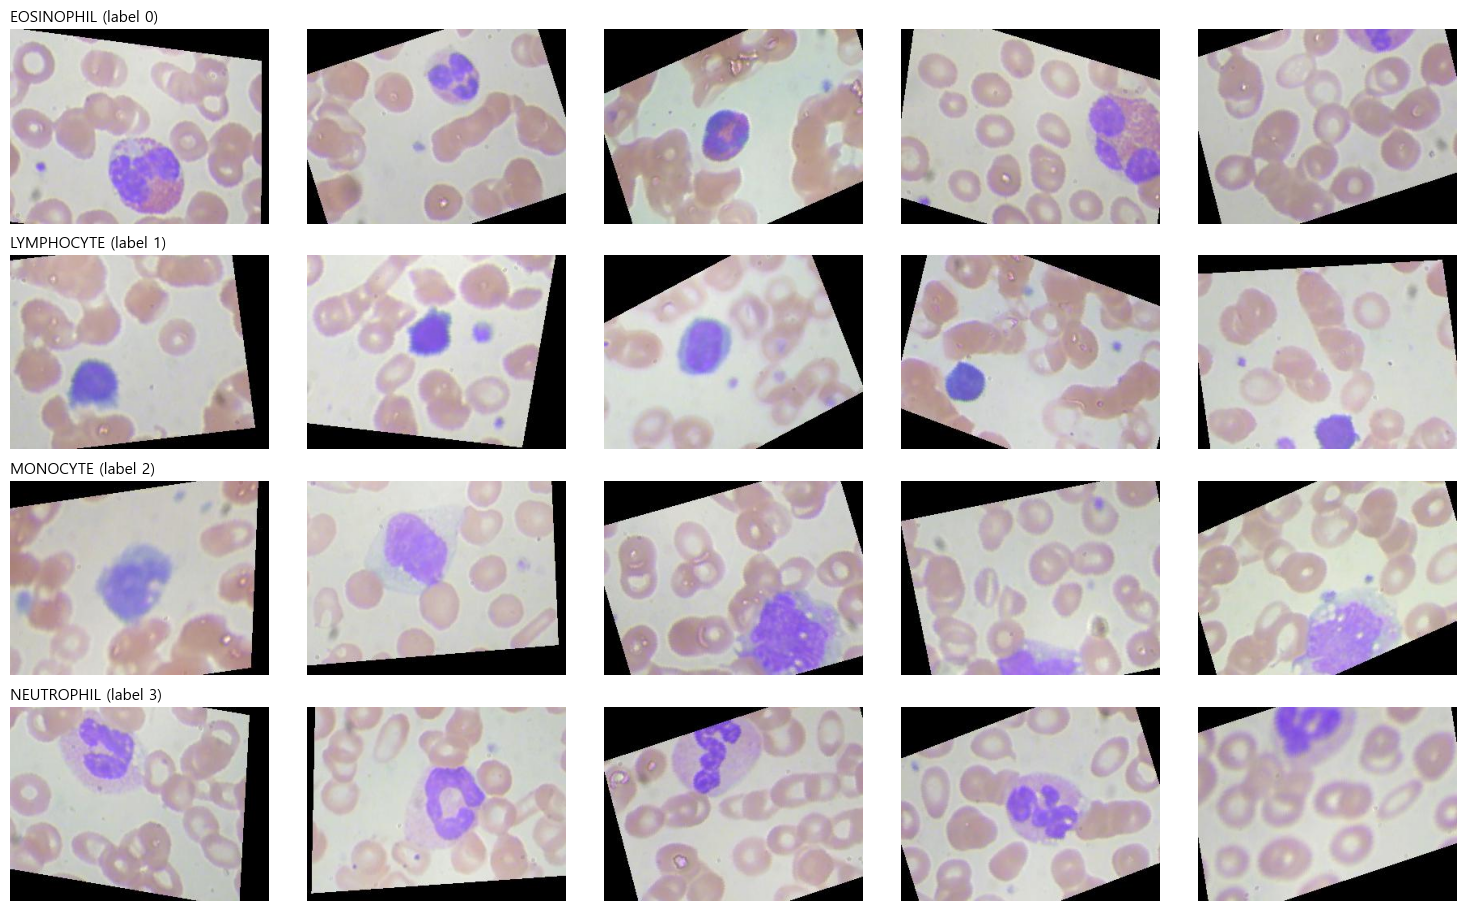

이미지 크기 (320, 240) | 모드 RGB


In [6]:
fig, axes = plt.subplots(NUM_CLASSES, 5, figsize=(15, 2.3 * NUM_CLASSES))
rng = np.random.RandomState(0)
for r, c in enumerate(CLASS_NAMES):
    d = os.path.join(DATA_DIR, 'TRAIN', c)
    fs = sorted(os.listdir(d))
    for k, f in enumerate(rng.choice(fs, min(5, len(fs)), replace=False)):
        axes[r, k].imshow(Image.open(os.path.join(d, f))); axes[r, k].axis('off')
    axes[r, 0].set_title(f'{c} (label {r})', loc='left', fontsize=11)
plt.tight_layout(); plt.show()

im = Image.open(os.path.join(DATA_DIR, 'TRAIN', CLASS_NAMES[0], sorted(os.listdir(os.path.join(DATA_DIR,'TRAIN',CLASS_NAMES[0])))[0]))
print('이미지 크기', im.size, '| 모드', im.mode)

### 관찰 5가지 — 전부 뒤 실험의 가설이 된다

1. **이미 증강된 데이터다.** 사진이 기울어져 있고 모서리에 검은 삼각형(회전 패딩)이 보인다.
   원본 366장을 회전·이동·확대해 12,444장으로 불린 것이다.
   → *회전을 또 크게 주면 패딩 위에 패딩을 쌓는 꼴이다.* (§11 에서 검증)
2. **판단 근거는 가운데 진한 보라색 세포 하나.** 주변 분홍 원반은 적혈구로 모든 클래스에 공통이다.
   → *배경을 보고 맞히면 안 된다.* (§17 CAM 으로 확인)
3. **클래스별 생김새**

   | 클래스 | 핵 | 세포질 |
   |---|---|---|
   | EOSINOPHIL | 두 덩이(이엽) | 분홍·주황 과립 |
   | LYMPHOCYTE | 작고 둥근 진한 핵 | 거의 없음 |
   | MONOCYTE | 콩팥·말굽 모양, 가장 큼 | 넓고 회청색 |
   | NEUTROPHIL | 3~5 덩이로 잘게 갈라짐 | 옅음 |

   → ***형태**가 핵심 신호, **색**이 보조 신호. 그래서 색 증강은 약하게만.*
4. **세포가 항상 가운데 있지 않다.** 강하게 자르면 세포를 잘라낸다.
5. 모든 이미지가 **320×240** 으로 크기가 일정하다.

### 소벨 필터로 확인 — "합성곱이 무엇을 보는가"

> **📘 수업 3-11**: 소벨 필터를 직접 씌워 **합성곱이 경계를 잡아낸다**는 걸 확인했다.
> CNN 의 첫 층들이 학습하는 것이 대체로 이런 종류의 필터다.
> 우리 데이터에서도 실제로 **핵의 경계**가 잡히는지 보자. 잡힌다면 CNN 이 이 문제에 적합하다는 근거다.

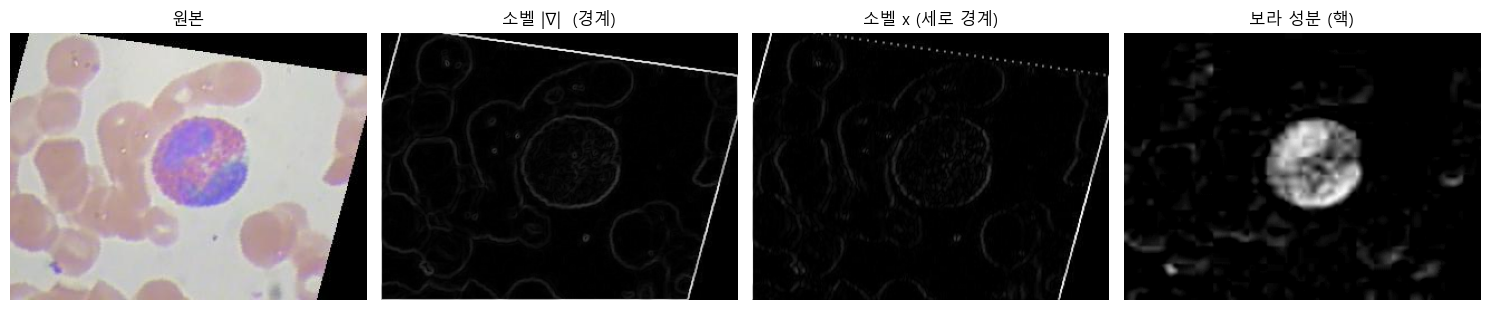

입력 (1, 1, 240, 320) → conv2d(3x3, padding=1) → (1, 1, 240, 320)
수업 3-11 출력 크기 공식: (입력 - 커널 + 2×패딩)/스트라이드 + 1 = (320 - 3 + 2×1)/1 + 1 = 320


In [7]:
sobel_x = torch.tensor([[-1., 0., 1.], [-2., 0., 2.], [-1., 0., 1.]]).view(1, 1, 3, 3)
sobel_y = torch.tensor([[-1., -2., -1.], [0., 0., 0.], [1., 2., 1.]]).view(1, 1, 3, 3)

g = torch.tensor(np.asarray(im.convert('L'), dtype=np.float32) / 255.)[None, None]
gx = F.conv2d(g, sobel_x, padding=1)
gy = F.conv2d(g, sobel_y, padding=1)
mag = (gx**2 + gy**2).sqrt()[0, 0]

# 보라색 채도 채널 — 핵만 골라내는 '손으로 만든 필터'
arr = np.asarray(im.convert('RGB'), dtype=np.float32) / 255.
purple = np.clip(arr[..., 2] - arr[..., 1], 0, 1)      # 파랑 - 초록 : 보라색일수록 크다

fig, ax = plt.subplots(1, 4, figsize=(15, 3.2))
for a, img, t in zip(ax, [np.asarray(im), mag.numpy(), gx[0,0].abs().numpy(), purple],
                     ['원본', '소벨 |∇|  (경계)', '소벨 x (세로 경계)', '보라 성분 (핵)']):
    a.imshow(img, cmap=None if t == '원본' else 'gray'); a.set_title(t); a.axis('off')
plt.tight_layout(); plt.show()

print('입력', tuple(g.shape), '→ conv2d(3x3, padding=1) →', tuple(gx.shape))
print('수업 3-11 출력 크기 공식: (입력 - 커널 + 2×패딩)/스트라이드 + 1 =',
      f'({g.shape[-1]} - 3 + 2×1)/1 + 1 = {(g.shape[-1] - 3 + 2)//1 + 1}')

경계 필터 하나만으로도 **핵의 윤곽**이 뚜렷하게 드러난다.
핵의 분엽 수(호중구 3~5개 vs 호산구 2개)가 클래스를 가르는 핵심이므로,
**경계를 잡는 합성곱이 이 문제에 잘 맞는다**는 근거가 된다.

---
# §4. 전처리와 증강

> **📘 수업 3-13 / 5-2**
> - 증강은 **학습용에만** 건다. **테스트·검증 데이터는 증강하지 않는다.**
>   (5장에서 `eval_full` 을 만들어 놓고 검증셋에 `train_tf` 를 쓴 버그를 지적했었다 — 여기선 고쳐 쓴다)
> - 정규화 값은 **ImageNet 통계**를 쓴다. ImageNet 사전학습 백본이 그 분포로 학습됐기 때문이다.
> - `Normalize` 는 항상 `ToTensor` **뒤**에 온다.

> **📘 수업 5-2 에서 배운 판단 방식**: X-ray 에는 회전을 주지 않았다. 촬영 자세가 정해져 있어서
> "있지도 않은 상황"을 학습시키게 되기 때문이다. **같은 논리를 여기 적용하면 결론이 반대가 된다.**

| 증강 | 이 데이터에서의 판단 | 이유 |
|---|---|---|
| 좌우/상하 반전 | **쓴다** | 세포는 방향성이 없다 (X-ray 의 심장 위치와 다르다) |
| 회전(추가) | **검증 대상** | 이미 회전이 걸려 있다 (§3) |
| 중앙 자르기 | **검증 대상** | 패딩 제거 vs 세포 손실 |
| 색 변화 | **약하게만** | 염색 색조가 클래스 신호 (호산구 과립) |
| RandomErasing | **불리할 것** | 판단 근거가 세포 하나뿐인데 가리면 라벨과 무관해진다 |

말로 정하지 않고 **§11 에서 실험으로 판정한다.**

In [8]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

PRESETS = {   # flip=반전, affine=회전각, color=색변화 강도, crop=중앙 비율, erase=지우기 확률
    'none'    : dict(flip=False, affine=0,  color=0.0, crop=1.00, erase=0.0),
    'flip'    : dict(flip=True,  affine=0,  color=0.0, crop=1.00, erase=0.0),
    'geo'     : dict(flip=True,  affine=15, color=0.0, crop=1.00, erase=0.0),
    'crop'    : dict(flip=True,  affine=0,  color=0.0, crop=0.80, erase=0.0),
    'color'   : dict(flip=True,  affine=0,  color=0.2, crop=1.00, erase=0.0),
    'crop_geo': dict(flip=True,  affine=10, color=0.1, crop=0.80, erase=0.0),
    'strong'  : dict(flip=True,  affine=15, color=0.2, crop=0.80, erase=0.25),
}

def build_transforms(preset='flip', image_size=224):
    """(학습용, 평가용) 두 벌을 만든다 — 수업 5-2 의 원칙"""
    p = PRESETS[preset]
    pre = []
    if p['crop'] < 1.0:
        pre.append(transforms.CenterCrop((int(240 * p['crop']), int(320 * p['crop']))))

    train_ops = pre + [transforms.Resize((image_size, image_size))]
    if p['flip']:
        train_ops += [transforms.RandomHorizontalFlip(), transforms.RandomVerticalFlip()]
    if p['affine'] > 0:
        train_ops += [transforms.RandomAffine(degrees=p['affine'], translate=(0.05, 0.05),
                                              scale=(0.9, 1.1))]
    if p['color'] > 0:
        c = p['color']
        train_ops += [transforms.ColorJitter(brightness=c, contrast=c, saturation=c*0.5, hue=c*0.1)]
    train_ops += [transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)]
    if p['erase'] > 0:
        train_ops += [transforms.RandomErasing(p=p['erase'], scale=(0.02, 0.10))]

    eval_ops = pre + [transforms.Resize((image_size, image_size)),
                      transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)]
    return transforms.Compose(train_ops), transforms.Compose(eval_ops)


def denorm(x):
    """정규화된 텐서를 다시 0~1 이미지로 (시각화용)"""
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1); std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return (x.detach().cpu() * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()

tr_tf, ev_tf = build_transforms('crop_geo', IMAGE_SIZE)
print(tr_tf)

Compose(
    CenterCrop(size=(192, 256))
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomVerticalFlip(p=0.5)
    RandomAffine(degrees=[-10.0, 10.0], translate=(0.05, 0.05), scale=(0.9, 1.1))
    ColorJitter(brightness=(0.9, 1.1), contrast=(0.9, 1.1), saturation=(0.95, 1.05), hue=(-0.010000000000000002, 0.010000000000000002))
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


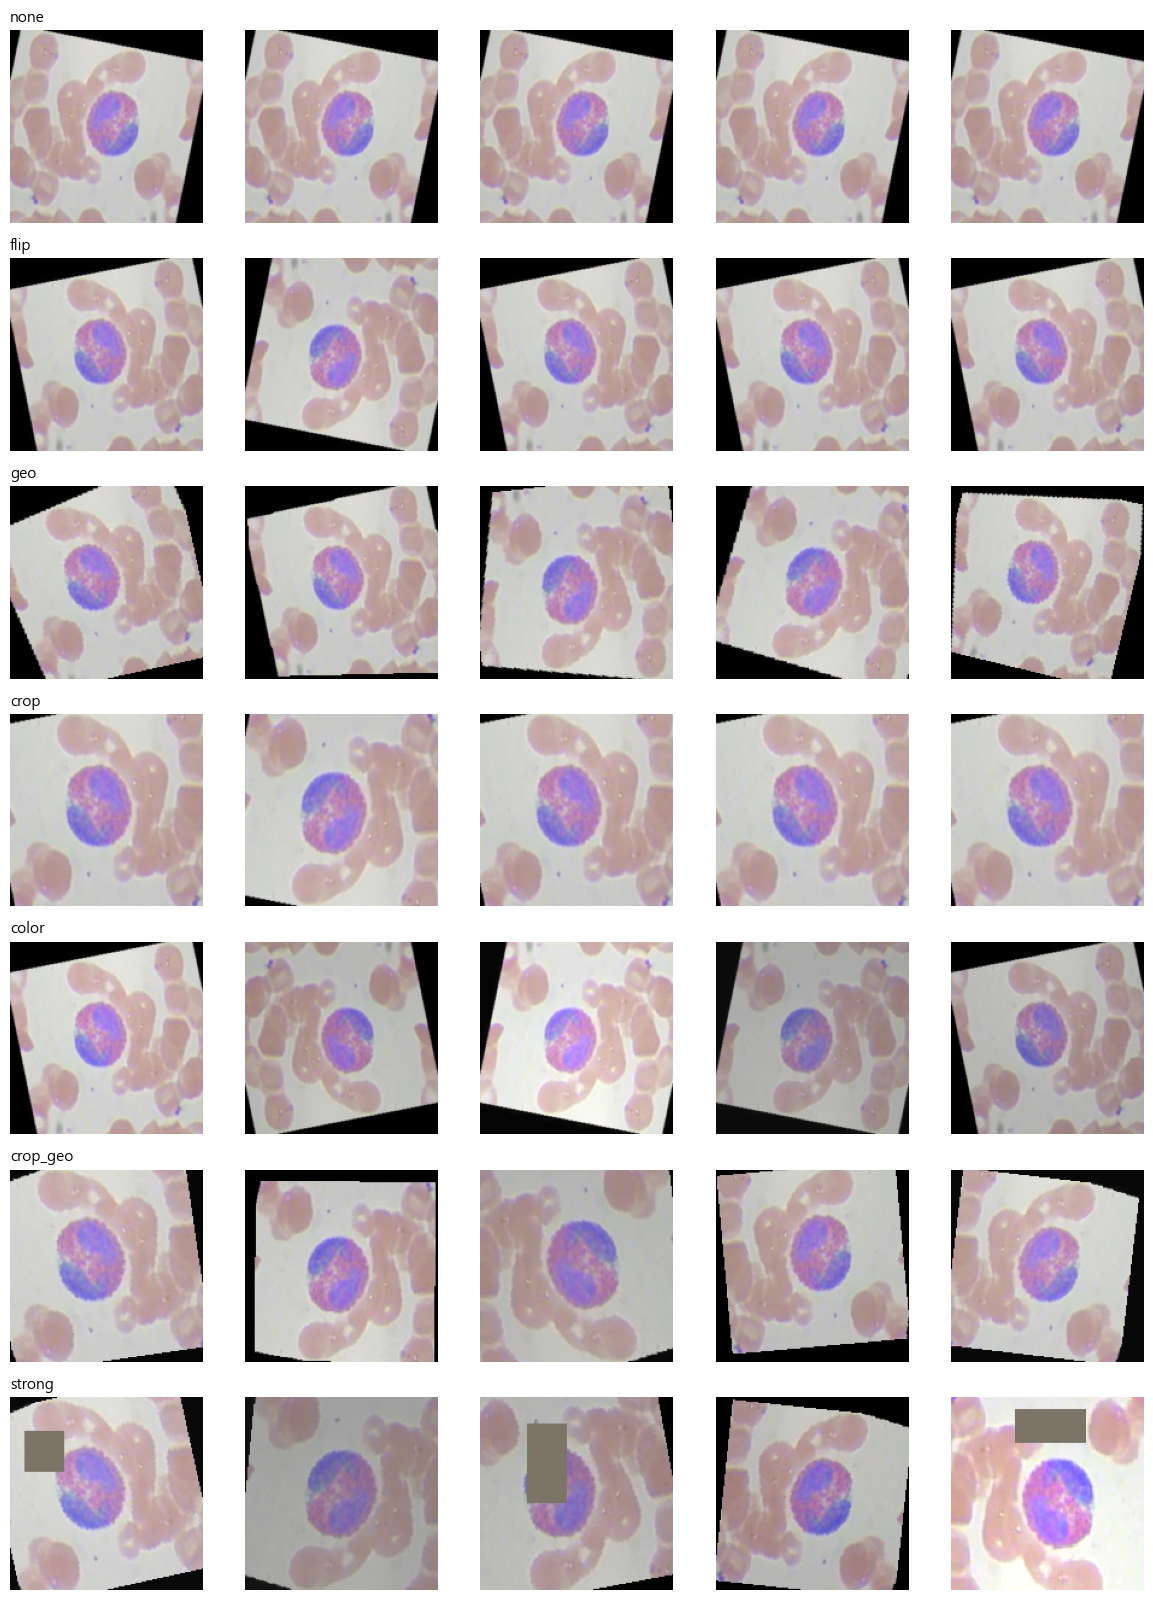

In [9]:
# 프리셋 7종을 눈으로 비교 — 같은 프리셋인데 매번 달라야 정상이다(무작위 증강)
fig, axes = plt.subplots(len(PRESETS), 5, figsize=(12, 2.3 * len(PRESETS)))
for r, p in enumerate(PRESETS):
    tf_, _ = build_transforms(p, 160)
    torch.manual_seed(0)
    for k in range(5):
        axes[r, k].imshow(denorm(tf_(im.convert('RGB')))); axes[r, k].axis('off')
    axes[r, 0].set_title(p, loc='left', fontsize=11)
plt.tight_layout(); plt.show()

---
# §5. 데이터로더 — 층화 분할

> **📘 수업 4-3**: `train_test_split(stratify=y)` 로 **층화 분할**을 했다.
> 클래스 비율을 train/val 에서 똑같이 유지하는 것이다.
> 5장에서는 `randperm` 으로 단순 무작위 분할을 해서 층화가 없었는데, **여기서는 층화를 쓴다.**

> **📘 수업 5-2 의 요령**: 같은 폴더를 **두 번 열어** 하나는 증강 있는 버전, 하나는 없는 버전으로 만들고
> 인덱스를 나눠 `Subset` 으로 자른다. 이렇게 해야 **검증셋에 증강이 걸리지 않는다.**

**TEST 폴더는 §16 전까지 열지 않는다.** 테스트셋을 보며 고르면 그 점수는 의미를 잃는다.

In [10]:
def make_loaders(preset='flip', image_size=224, batch_size=64, val_ratio=0.2,
                 split_seed=42, subset=None):
    train_tf, eval_tf = build_transforms(preset, image_size)

    train_full = datasets.ImageFolder(os.path.join(DATA_DIR, 'TRAIN'), transform=train_tf)  # 증강 있음
    eval_full  = datasets.ImageFolder(os.path.join(DATA_DIR, 'TRAIN'), transform=eval_tf)   # 증강 없음
    test_set   = datasets.ImageFolder(os.path.join(DATA_DIR, 'TEST'),  transform=eval_tf)

    # --- 층화 분할 (수업 4-3) : 클래스마다 따로 섞어 같은 비율로 자른다
    targets = np.array(train_full.targets)
    rng = np.random.RandomState(split_seed)
    val_idx, train_idx = [], []
    for c in range(NUM_CLASSES):
        idx = np.where(targets == c)[0]; rng.shuffle(idx)
        n_val = int(len(idx) * val_ratio)
        val_idx += idx[:n_val].tolist(); train_idx += idx[n_val:].tolist()
    rng.shuffle(train_idx)
    if subset: train_idx = train_idx[:subset]

    train_set = Subset(train_full, train_idx)     # 증강 O
    val_set   = Subset(eval_full,  val_idx)       # 증강 X  ← 5장 버그를 고친 부분

    kw = dict(num_workers=NUM_WORKERS, pin_memory=(device.type == 'cuda'),
              persistent_workers=(NUM_WORKERS > 0))
    return (DataLoader(train_set, batch_size=batch_size, shuffle=True, drop_last=True, **kw),
            DataLoader(val_set,   batch_size=batch_size*2, shuffle=False, **kw),
            DataLoader(test_set,  batch_size=batch_size*2, shuffle=False, **kw))

train_loader, val_loader, test_loader = make_loaders('flip', IMAGE_SIZE, BATCH_SIZE)
print(f'train {len(train_loader.dataset)} / val {len(val_loader.dataset)} / test {len(test_loader.dataset)}')

xb, yb = next(iter(train_loader))
print('배치 모양', tuple(xb.shape), '| 라벨 dtype', yb.dtype, '| 예시', yb[:8].tolist())
print('층화 확인 — 검증셋 클래스 분포:',
      np.bincount([val_loader.dataset.dataset.targets[i] for i in val_loader.dataset.indices],
                  minlength=NUM_CLASSES))

train 7968 / val 1989 / test 2487
배치 모양 (64, 3, 224, 224) | 라벨 dtype torch.int64 | 예시 [1, 2, 2, 0, 1, 3, 2, 1]
층화 확인 — 검증셋 클래스 분포: [499 496 495 499]


> **📘 수업 5-4 와 달라지는 점**: 5장에서는 `ImageFolder` 라벨이 `long` 이라
> `BCEWithLogitsLoss` 에 넣으려고 `.float()` 로 바꿔야 했다.
> **`CrossEntropyLoss` 는 정수 라벨(`long`)을 그대로 받는다.** 변환이 필요 없다.
> 위 출력의 `라벨 dtype = torch.int64` 가 그것이다.

---
# §6. 모델 4종

> **📘 수업 2-3**: `nn.Module` 을 상속하고 `__init__` 에 층을 만들고 `forward` 에 흐름을 쓴다.
> **출력층에 softmax 를 붙이지 않는다** — `CrossEntropyLoss` 가 안에서 처리한다(0장 대응표).

네 가지를 만들어 **전이학습의 효과를 단계적으로 잰다.**

| 모델 | 수업 | 무엇을 재는가 |
|---|---|---|
| **A. SimpleCNN** | 3-12 | 밑바닥 CNN 으로 얼마나 되나 |
| **B. MyResNet18** | 3-14 | 잔차 연결을 직접 구현. 구조가 깊어지면 나아지나 |
| **C. 전이학습(백본 고정)** | 4-6 | ImageNet 특징만으로 되나 |
| **D. 전이학습(전체 미세조정)** | 5-3 | 본 게임 |

네 모델 모두 **`특징맵 → GAP → Linear` 로 끝난다.** 이 구조여야 §17 의 CAM 을 근사 없이 뽑을 수 있다.

In [11]:
class SimpleCNN(nn.Module):
    """A. 밑바닥 CNN — 수업 3-12 (Conv-BN-ReLU 2개 + MaxPool 을 4단)"""
    def __init__(self, num_classes=NUM_CLASSES, width=32):
        super().__init__()
        def block(i, o):
            return nn.Sequential(
                nn.Conv2d(i, o, 3, padding=1), nn.BatchNorm2d(o), nn.ReLU(inplace=True),
                nn.Conv2d(o, o, 3, padding=1), nn.BatchNorm2d(o), nn.ReLU(inplace=True),
                nn.MaxPool2d(2))
        self.features = nn.Sequential(block(3, width), block(width, width*2),
                                      block(width*2, width*4), block(width*4, width*8))
        self.pool = nn.AdaptiveAvgPool2d(1)          # GAP
        self.head = nn.Linear(width*8, num_classes)  # 선형 한 층 → CAM 가능

    def forward_features(self, x):                   # CAM 을 위해 특징맵을 따로 꺼낸다
        return self.features(x)

    def forward(self, x):
        return self.head(self.pool(self.forward_features(x)).flatten(1))

### B. 잔차 연결을 직접 구현 — 수업 3-14

> **📘 수업 3-14**: 층이 깊어지면 기울기가 사라져 학습이 안 된다.
> 해결이 **잔차 연결(shortcut)** 이다. 블록의 출력에 입력을 그대로 더한다.
>
> $$y = F(x) + x$$
>
> `shortcut` 이 조건부인 이유: 채널 수나 크기가 바뀌면 그냥 더할 수 없으므로
> **1×1 합성곱으로 모양을 맞춰 준다.**

수업에서 조립한 ResNet18 을 그대로 가져오되, 마지막을 4클래스로 바꾼다.

In [12]:
class BasicBlock(nn.Module):
    """수업 3-14 의 잔차 블록"""
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, stride=1, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_ch)
        # 모양이 달라질 때만 1x1 합성곱으로 맞춘다  ← shortcut 이 조건부인 이유
        self.shortcut = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False),
                                          nn.BatchNorm2d(out_ch))

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = out + self.shortcut(x)          # ← 잔차 연결
        return F.relu(out)


class MyResNet18(nn.Module):
    """B. 수업 3-14 에서 조립한 ResNet18 (사전학습 없음)"""
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        self.stem = nn.Sequential(nn.Conv2d(3, 64, 7, stride=2, padding=3, bias=False),
                                  nn.BatchNorm2d(64), nn.ReLU(inplace=True),
                                  nn.MaxPool2d(3, stride=2, padding=1))
        self.layer1 = nn.Sequential(BasicBlock(64, 64),   BasicBlock(64, 64))
        self.layer2 = nn.Sequential(BasicBlock(64, 128, 2),  BasicBlock(128, 128))
        self.layer3 = nn.Sequential(BasicBlock(128, 256, 2), BasicBlock(256, 256))
        self.layer4 = nn.Sequential(BasicBlock(256, 512, 2), BasicBlock(512, 512))
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.head = nn.Linear(512, num_classes)
        self._init_weights()

    def _init_weights(self):
        """수업 3-15: He(kaiming) 초기화. ReLU 를 쓰는 층에 맞는 초기화다"""
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1); nn.init.constant_(m.bias, 0)

    def forward_features(self, x):
        x = self.stem(x)
        return self.layer4(self.layer3(self.layer2(self.layer1(x))))

    def forward(self, x):
        return self.head(self.pool(self.forward_features(x)).flatten(1))

### C·D. 전이학습 — 수업 4-6 / 5-3

> **📘 수업 5-3**: `timm.create_model(이름, pretrained=True, num_classes=0, global_pool='avg')`
> 로 분류층을 떼고 백본만 가져온다. 출력 크기는 `backbone.num_features` 로 **자동으로** 알아낸다
> (4장처럼 1280 을 손으로 적으면 백본을 바꿀 때마다 틀린다).
>
> 여기서는 CAM 을 뽑아야 하므로 **`global_pool=''` 로 풀링까지 끄고 특징맵을 받은 뒤**
> GAP 를 직접 건다.

> **📘 수업 4-6**: `requires_grad = False` 로 백본을 얼리면 **헤드만 학습**한다.
> 4장에서 가장 인상적인 숫자가 이거였다 — 학습 파라미터 1,281개 vs 전체 2,376만개.

In [13]:
import timm

class TransferNet(nn.Module):
    """C(freeze=True) / D(freeze=False) — 수업 4-6, 5-3"""
    def __init__(self, backbone='resnet18', num_classes=NUM_CLASSES, pretrained=True,
                 freeze=False, dropout=0.0, probe_size=224):
        super().__init__()
        self.backbone = timm.create_model(backbone, pretrained=pretrained,
                                          num_classes=0, global_pool='')   # 분류층·풀링 제거
        with torch.no_grad():                       # 채널 수는 더미 입력으로 확인한다
            n_feat = self._to_map(self.backbone(torch.zeros(1, 3, probe_size, probe_size))).shape[1]
        self.num_features = n_feat
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.drop = nn.Dropout(dropout)             # 수업 2-10
        self.head = nn.Linear(n_feat, num_classes)
        if freeze:                                  # 수업 4-6: 백본 고정
            for p in self.backbone.parameters():
                p.requires_grad = False

    @staticmethod
    def _to_map(f):
        if f.dim() == 3:                            # ViT 계열은 (B,N,C) → 격자로 되돌린다
            n = f.shape[1]; s = int(round(math.sqrt(n)))
            f = f[:, n - s*s:, :].transpose(1, 2).reshape(f.shape[0], -1, s, s)
        return f

    def forward_features(self, x):
        return self._to_map(self.backbone(x))

    def forward(self, x):
        return self.head(self.drop(self.pool(self.forward_features(x)).flatten(1)))


def build_model(name, pretrained=True, freeze=False, dropout=0.0, image_size=224):
    if name == 'simplecnn':  return SimpleCNN()
    if name == 'myresnet18': return MyResNet18()
    return TransferNet(name, pretrained=pretrained, freeze=freeze,
                       dropout=dropout, probe_size=image_size)

def count_params(model):
    tot = sum(p.numel() for p in model.parameters())
    trn = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return tot, trn

c:\Users\KDS23\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [14]:
# 수업 5-3 의 습관: 만들자마자 더미 입력을 흘려 shape 을 확인한다
print(f"{'모델':26s}{'특징맵':>18s}{'출력':>10s}{'전체 파라미터':>16s}{'학습 파라미터':>16s}")
for name, kw in [('simplecnn', {}), ('myresnet18', {}),
                 ('resnet18 (고정)', dict(name='resnet18', freeze=True)),
                 ('resnet18 (미세조정)', dict(name='resnet18', freeze=False))]:
    kw = dict(kw); nm = kw.pop('name', name)
    m = build_model(nm, pretrained=('resnet' in nm and nm != 'myresnet18'), image_size=224, **kw)
    with torch.no_grad():
        f = m.forward_features(torch.zeros(1, 3, 224, 224)); o = m(torch.zeros(1, 3, 224, 224))
    tot, trn = count_params(m)
    print(f'{name:26s}{str(tuple(f.shape)):>18s}{str(tuple(o.shape)):>10s}{tot:>16,}{trn:>16,}')
    del m

모델                                       특징맵        출력         전체 파라미터         학습 파라미터
simplecnn                   (1, 256, 14, 14)    (1, 4)       1,175,204       1,175,204
myresnet18                    (1, 512, 7, 7)    (1, 4)      11,178,564      11,178,564


resnet18 (고정)                 (1, 512, 7, 7)    (1, 4)      11,178,564           2,052
resnet18 (미세조정)               (1, 512, 7, 7)    (1, 4)      11,178,564      11,178,564


**수업 4-6 에서 본 그 숫자가 여기서도 나온다.**
백본을 고정하면 학습 파라미터가 **2,052개**(512×4+4)로 줄어든다. 전체의 0.02% 다.
그만큼 빠르지만, ImageNet 특징이 이 도메인에 맞지 않으면 성능이 따라오지 못한다. §9 에서 확인한다.

---
# §7. 학습 루프와 평가 함수 — 이 노트북의 심장

> **📘 수업 2-5 — 학습 루프 다섯 줄. 이 순서가 전부다.**
> ```python
> optimizer.zero_grad()               # 1. 이전 기울기 지우기
> output = model(data)                # 2. 순전파
> loss = criterion(output, target)    # 3. 손실 계산
> loss.backward()                     # 4. 역전파
> optimizer.step()                    # 5. 가중치 갱신
> ```
> **`zero_grad()` 를 빼면 기울기가 누적된다.** 파이토치에서 가장 많이 하는 실수다.
> 케라스의 `model.fit()` 안에서도 이 다섯 줄이 돌아간다. 파이토치는 그걸 밖으로 꺼내 놓은 것뿐이다.

> **📘 수업 2-8 — 평가할 때 반드시 두 가지**
> `model.eval()` (드롭아웃·BatchNorm 동작 전환) + `torch.no_grad()` (기울기 계산 끄기).
> **하는 일이 다르므로 둘 다** 써야 한다.

> **📘 수업 2-1 정정사항 반영**: 수업 `2.ipynb` 는 에폭마다 **마지막 배치의 손실**만 출력해서
> 값이 들쭉날쭉했다. 여기서는 **에폭 평균**을 낸다 (`loss.item() * len(yb)` 를 누적해서 나눈다).

In [15]:
@torch.no_grad()                                   # ← 수업 2-8
def evaluate(model, loader, criterion=None):
    """평가. 4·5장의 이진분류 evaluate 를 다중분류로 바꾼 것"""
    model.eval()                                   # ← 수업 2-8
    losses, probs, trues = [], [], []
    for xb, yb in loader:
        xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
        logits = model(xb)                         # (B, 4)  ← 4·5장은 squeeze(1) 했다
        if criterion is not None:
            losses.append(criterion(logits, yb).item() * len(yb))
        probs.append(torch.softmax(logits.float(), dim=1).cpu().numpy())   # ← sigmoid 아님
        trues.append(yb.cpu().numpy())

    probs = np.concatenate(probs); trues = np.concatenate(trues)
    preds = probs.argmax(1)                        # ← 4·5장은 (sigmoid > 0.5)
    try:
        auc = roc_auc_score(trues, probs, multi_class='ovr', average='macro')
    except ValueError:
        auc = float('nan')
    return {'loss': (sum(losses)/len(trues)) if criterion is not None else float('nan'),
            'accuracy': accuracy_score(trues, preds),
            'balanced': balanced_accuracy_score(trues, preds),
            'macro_f1': f1_score(trues, preds, average='macro'),
            'macro_prec': precision_score(trues, preds, average='macro', zero_division=0),
            'macro_rec': recall_score(trues, preds, average='macro', zero_division=0),
            'auc': auc, 'probs': probs, 'trues': trues, 'preds': preds}

### 이진 분류(4·5장) → 다중 분류(이 프로젝트) 대응표

| | 4·5장 (이진) | 이 프로젝트 (4클래스) |
|---|---|---|
| 출력층 | `nn.Linear(n, 1)` | **`nn.Linear(n, 4)`** |
| 손실 | `BCEWithLogitsLoss` | **`CrossEntropyLoss`** (안에서 softmax 처리) |
| 로짓 | `model(x).squeeze(1)` | **`model(x)`** — squeeze 안 함 |
| 확률 | `torch.sigmoid(logits)` | **`torch.softmax(logits, dim=1)`** |
| 예측 | `probs > 0.5` | **`probs.argmax(1)`** |
| 라벨 | `.float()` 로 변환 필요 | **`long` 그대로** |
| 지표 | 정확도·정밀도·재현율·AUC | **+ macro 평균** (클래스가 4개니까) |

In [16]:
def train_model(model, train_loader, val_loader, epochs=10, lr=3e-4, weight_decay=1e-4,
                label_smoothing=0.0, scheduler='plateau', patience=4, monitor='macro_f1',
                ckpt_path='./results/ckpt/tmp.pt', label='model', amp=True, verbose=True):
    """수업 2-5 의 다섯 줄에 스케줄러·체크포인트·조기종료·시간측정을 붙인 것"""
    model = model.to(device)                                   # ← 모델을 장치로
    criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
    params = [p for p in model.parameters() if p.requires_grad]   # 고정된 백본은 제외
    optimizer = torch.optim.AdamW(params, lr=lr, weight_decay=weight_decay)

    # --- 수업 2-9 / 3-15 : 학습률 스케줄러
    if scheduler == 'cosine':
        sched = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    elif scheduler == 'step':
        sched = torch.optim.lr_scheduler.StepLR(optimizer, step_size=max(1, epochs//3), gamma=0.3)
    else:                                                       # 'plateau'
        sched = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.3,
                                                           patience=2, min_lr=1e-7)
    use_amp = bool(amp and device.type == 'cuda')               # 혼합정밀 — 3분 예산을 맞추는 가장 싼 수단
    scaler = torch.amp.GradScaler('cuda', enabled=use_amp)

    hist = {k: [] for k in ['loss','accuracy','val_loss','val_accuracy','val_macro_f1','val_auc','lr','sec']}
    best, best_epoch, bad = -float('inf'), 0, 0

    for epoch in range(1, epochs + 1):
        model.train()                                          # ← 수업 2-8: 학습 모드
        run_loss, run_correct, n = 0.0, 0, 0
        if device.type == 'cuda': torch.cuda.synchronize()     # ← 수업 1장: GPU 시간 측정
        t0 = time.time()

        for xb, yb in train_loader:
            xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)

            # ===== 수업 2-5. 학습 루프 다섯 줄 =====
            optimizer.zero_grad(set_to_none=True)              # 1. 이전 기울기 지우기
            with torch.amp.autocast('cuda', enabled=use_amp):
                logits = model(xb)                             # 2. 순전파
                loss = criterion(logits, yb)                   # 3. 손실 계산
            scaler.scale(loss).backward()                      # 4. 역전파
            scaler.step(optimizer); scaler.update()            # 5. 가중치 갱신
            # =====================================

            run_loss += loss.item() * len(yb)                  # 에폭 평균을 내려고 누적
            run_correct += (logits.argmax(1) == yb).sum().item()
            n += len(yb)

        tr_loss, tr_acc = run_loss / n, run_correct / n
        m = evaluate(model, val_loader, criterion)
        if device.type == 'cuda': torch.cuda.synchronize()
        sec = time.time() - t0

        # 스케줄러는 '검증' 손실로 판단한다 (수업 2.ipynb 는 학습 손실을 넣는 실수가 있었다)
        sched.step(m['loss']) if scheduler == 'plateau' else sched.step()

        for k, v in [('loss',tr_loss), ('accuracy',tr_acc), ('val_loss',m['loss']),
                     ('val_accuracy',m['accuracy']), ('val_macro_f1',m['macro_f1']),
                     ('val_auc',m['auc']), ('lr',optimizer.param_groups[0]['lr']), ('sec',sec)]:
            hist[k].append(v)

        score = m['macro_f1'] if monitor == 'macro_f1' else -m['loss']
        star = ''
        if score > best:
            best, best_epoch, bad = score, epoch, 0
            torch.save(model.state_dict(), ckpt_path)          # ← 수업 2-6: state_dict 만 저장
            star = '저장'
        else:
            bad += 1

        if verbose:
            over = ' ⚠3분초과' if sec > EPOCH_BUDGET else ''
            print(f"[{label}] {epoch:2d}/{epochs} loss {tr_loss:.4f} acc {tr_acc:.4f} | "
                  f"val_loss {m['loss']:.4f} val_acc {m['accuracy']:.4f} val_f1 {m['macro_f1']:.4f} "
                  f"val_auc {m['auc']:.4f} | lr {optimizer.param_groups[0]['lr']:.1e} "
                  f"({sec:.0f}s){over} {star}")

        if bad >= patience:                                    # 조기종료
            if verbose: print(f'  조기종료: {patience} 에폭 동안 개선 없음')
            break

    hist.update(best_epoch=best_epoch, best_score=best, ckpt_path=ckpt_path,
                epoch_sec_mean=float(np.mean(hist['sec'])), epochs_run=len(hist['loss']))
    if verbose:
        print(f"best {monitor} = {best:.4f} @epoch {best_epoch} → {ckpt_path}")
        print(f"에폭당 평균 {hist['epoch_sec_mean']:.0f}초 (예산 {EPOCH_BUDGET}초) "
              f"| 총 {hist['epochs_run']}에폭 {sum(hist['sec'])/60:.1f}분")
    return hist

### 실험 기록 — "무한하게 반복"을 감당하는 장치

실험을 수십 번 돌릴 것이므로, 결과를 사람이 기억하지 않게 만든다.

- 모든 실험이 `results/runs.csv` 에 **한 줄씩 누적**된다
- **이미 돌린 `run_id` 는 자동으로 건너뛴다** → 노트북을 다시 실행해도 이어서 진행된다
- 예측 확률을 `results/preds/*.npz` 에 저장한다 → **§19 의 McNemar 검정은 재학습 없이** 가능하다

In [17]:
RUNS_CSV = f'{RESULT_DIR}/runs.csv'

def already_run(run_id):
    if not os.path.exists(RUNS_CSV): return False
    with open(RUNS_CSV, newline='', encoding='utf-8-sig') as f:
        return any(r.get('run_id') == run_id for r in csv.DictReader(f))

def log_run(run_id, params, val_m=None, test_m=None, hist=None):
    row = dict(run_id=run_id, **params)
    for tag, m in [('val', val_m), ('test', test_m)]:
        if m is None: continue
        for k in ['accuracy','balanced','macro_f1','macro_prec','macro_rec','auc','loss']:
            row[f'{tag}_{k}'] = round(float(m[k]), 5)
    if hist is not None:
        row['best_epoch'] = hist['best_epoch']; row['epochs_run'] = hist['epochs_run']
        row['epoch_sec'] = round(hist['epoch_sec_mean'], 1)
    save = {}
    if val_m  is not None: save.update(val_probs=val_m['probs'],  val_trues=val_m['trues'])
    if test_m is not None: save.update(test_probs=test_m['probs'], test_trues=test_m['trues'])
    if save: np.savez_compressed(f'{RESULT_DIR}/preds/{run_id}.npz', **save)

    old = []
    if os.path.exists(RUNS_CSV):
        with open(RUNS_CSV, newline='', encoding='utf-8-sig') as f: old = list(csv.DictReader(f))
    keys = sorted(set().union(*[set(r) for r in old + [row]])) if old else list(row)
    with open(RUNS_CSV, 'w', newline='', encoding='utf-8-sig') as f:
        w = csv.DictWriter(f, fieldnames=keys); w.writeheader()
        for r in old + [row]: w.writerow(r)
    return row

def runs_table():
    return pd.read_csv(RUNS_CSV, encoding='utf-8-sig') if os.path.exists(RUNS_CSV) else pd.DataFrame()

def summarize(m, name=''):
    return (f"{name:24s} acc {m['accuracy']:.4f}  macroF1 {m['macro_f1']:.4f}  "
            f"balanced {m['balanced']:.4f}  AUC {m['auc']:.4f}")


def run_experiment(run_id, model_name='resnet18', preset='flip', image_size=None, batch_size=None,
                   lr=3e-4, epochs=None, freeze=False, pretrained=True, dropout=0.0,
                   weight_decay=1e-4, label_smoothing=0.0, scheduler='plateau', seed=42,
                   subset=None, patience=3, force=False, verbose=True):
    """실험 한 건: 로더 → 모델 → 학습 → 최적 가중치 복원 → 검증 평가 → 기록"""
    if already_run(run_id) and not force:
        if verbose: print(f'[건너뜀] {run_id} — 이미 runs.csv 에 있음'); 
        return None
    image_size = image_size or IMAGE_SIZE; batch_size = batch_size or BATCH_SIZE
    epochs = epochs or SCREEN_EPOCHS

    set_seed(seed)
    tr, va, te = make_loaders(preset, image_size, batch_size, subset=subset)
    model = build_model(model_name, pretrained=pretrained, freeze=freeze,
                        dropout=dropout, image_size=image_size)
    tot, trn = count_params(model)
    if verbose:
        print(f'=== {run_id} | {model_name} | {preset} | {image_size}px bs{batch_size} '
              f'lr{lr:g} seed{seed} | 학습 파라미터 {trn:,}/{tot:,}')
    hist = train_model(model, tr, va, epochs=epochs, lr=lr, weight_decay=weight_decay,
                       label_smoothing=label_smoothing, scheduler=scheduler, patience=patience,
                       ckpt_path=f'{RESULT_DIR}/ckpt/{run_id}.pt', label=run_id, verbose=verbose)
    model.load_state_dict(torch.load(hist['ckpt_path'], map_location=device))   # 최적 시점 복원
    mv = evaluate(model, va, nn.CrossEntropyLoss())
    log_run(run_id, dict(model=model_name, preset=preset, image_size=image_size,
                         batch_size=batch_size, lr=lr, freeze=int(freeze), pretrained=int(pretrained),
                         dropout=dropout, weight_decay=weight_decay, label_smoothing=label_smoothing,
                         scheduler=scheduler, seed=seed, subset=subset or 0,
                         params_M=round(tot/1e6, 2)), mv, None, hist)
    if verbose: print(summarize(mv, '  VAL'))
    return dict(model=model, history=hist, val=mv)

In [18]:
def plot_history(hist, title=''):
    """학습 곡선 — 손실 / 정확도 / macro-F1 / 학습률"""
    fig, ax = plt.subplots(1, 4, figsize=(17, 3.4))
    e = range(1, len(hist['loss']) + 1)
    ax[0].plot(e, hist['loss'], marker='o', label='train'); ax[0].plot(e, hist['val_loss'], marker='o', label='val')
    ax[0].set_title(f'{title} 손실'); ax[0].legend()
    ax[1].plot(e, hist['accuracy'], marker='o', label='train'); ax[1].plot(e, hist['val_accuracy'], marker='o', label='val')
    ax[1].set_title('정확도'); ax[1].legend()
    ax[2].plot(e, hist['val_macro_f1'], marker='o', color='tab:green'); ax[2].set_title('검증 macro-F1')
    ax[3].plot(e, hist['lr'], marker='o', color='tab:red'); ax[3].set_yscale('log'); ax[3].set_title('학습률')
    for a in ax: a.set_xlabel('epoch'); a.grid(alpha=.3)
    plt.tight_layout(); plt.show()


def plot_confusion(y_true, y_pred, normalize=False, title='혼동행렬'):
    """수업 2-8 / 5-4 의 혼동행렬. 5장에서 지적된 '정규화를 imshow 앞으로' 를 반영했다"""
    cm = confusion_matrix(y_true, y_pred)
    shown = cm.astype(float) / cm.sum(axis=1, keepdims=True) if normalize else cm
    fig, ax = plt.subplots(figsize=(5.2, 4.6))
    im_ = ax.imshow(shown, interpolation='nearest', cmap=plt.cm.Blues)
    ax.set_title(title); fig.colorbar(im_, ax=ax)
    ticks = np.arange(len(CLASS_NAMES))
    ax.set_xticks(ticks); ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
    ax.set_yticks(ticks); ax.set_yticklabels(CLASS_NAMES)
    thr = shown.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        ax.text(j, i, f'{shown[i,j]:.2f}' if normalize else f'{cm[i,j]}',
                ha='center', color='white' if shown[i, j] > thr else 'black')
    ax.set_ylabel('정답'); ax.set_xlabel('예측'); plt.tight_layout(); plt.show()
    return cm

---
# §8. 속도 측정 — "1 에폭 최대 3분" 조건

**모델을 고르기 전에 시간을 먼저 잰다.** 고르고 나서 재면 조건을 못 맞췄을 때 처음부터 다시 해야 한다.

> **📘 수업 1장**: GPU 연산은 **비동기**다. 시간을 재려면 `torch.cuda.synchronize()` 를 불러
> 실제로 끝나기를 기다려야 한다. 안 그러면 실제보다 빠르게 측정된다.

> **왜 이게 필요한가**: 수업 5장에서 ResNetV2-50 은 4,173장에 **200초/에폭**이었다.
> 우리 학습셋은 약 7,966장으로 **거의 두 배**다. 같은 속도라면 380초 → **조건 위반**.
> "수업에서 쓴 모델"을 그대로 가져오면 안 된다는 뜻이다.

In [19]:
N_TRAIN = int(len(datasets.ImageFolder(os.path.join(DATA_DIR,'TRAIN')).samples) * 0.8)

def speed_probe(model_name, image_size=224, batch_size=64, n_batches=10, freeze=False):
    """더미 배치만 흘려 초당 처리량을 재고 1 에폭 예상시간을 계산"""
    set_seed(0)
    model = build_model(model_name, pretrained=False, freeze=freeze, image_size=image_size).to(device)
    opt = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=1e-4)
    crit = nn.CrossEntropyLoss()
    use_amp = device.type == 'cuda'
    scaler = torch.amp.GradScaler('cuda', enabled=use_amp)
    x = torch.randn(batch_size, 3, image_size, image_size, device=device)
    y = torch.randint(0, NUM_CLASSES, (batch_size,), device=device)

    model.train()
    for i in range(n_batches + 3):
        if i == 3:                                     # 워밍업 3배치 제외
            if device.type == 'cuda': torch.cuda.synchronize()
            t0 = time.time()
        opt.zero_grad(set_to_none=True)
        with torch.amp.autocast('cuda', enabled=use_amp):
            loss = crit(model(x), y)
        scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
    if device.type == 'cuda': torch.cuda.synchronize()   # ← 수업 1장
    dt = time.time() - t0

    ips = n_batches * batch_size / dt
    est = N_TRAIN / ips * 1.25                          # 검증·데이터로딩 몫 25% 가산
    tot, _ = count_params(model)
    del model, opt
    if device.type == 'cuda': torch.cuda.empty_cache()
    return dict(model=model_name, image_size=image_size, batch_size=batch_size,
                params_M=round(tot/1e6, 2), img_per_sec=round(ips, 1),
                est_epoch_sec=round(est, 1), fits=est <= EPOCH_BUDGET)

,model,image_size,batch_size,params_M,img_per_sec,est_epoch_sec,판정
0,simplecnn,224,64,1.18,504.7,19.7,○ 3분 이내
1,myresnet18,224,64,11.18,1106.5,9.0,○ 3분 이내
2,resnet18,224,64,11.18,1098.9,9.1,○ 3분 이내
3,resnet18,160,64,11.18,2016.8,4.9,○ 3분 이내
4,efficientnet_b0,224,64,4.01,685.2,14.5,○ 3분 이내
5,mobilenetv3_small_100,224,64,1.52,2419.7,4.1,○ 3분 이내
6,resnetv2_50,224,64,23.51,411.3,24.2,○ 3분 이내


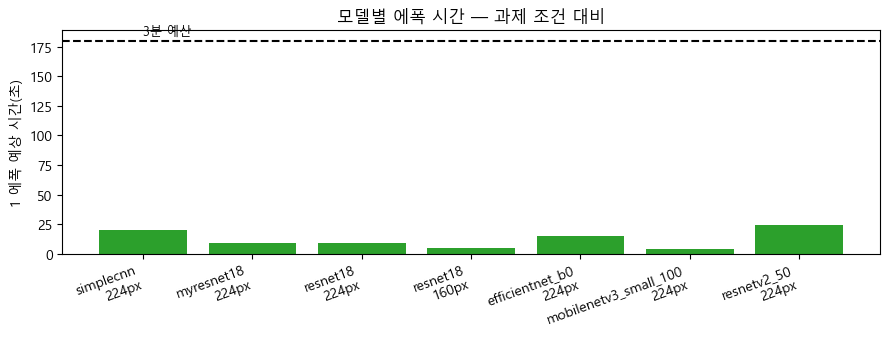

In [20]:
cands = [('simplecnn', 224, 64), ('myresnet18', 224, 64), ('resnet18', 224, 64),
         ('resnet18', 160, 64), ('efficientnet_b0', 224, 64),
         ('mobilenetv3_small_100', 224, 64), ('resnetv2_50', 224, 64)]
rows = []
for name, size, bs in cands:
    try:
        rows.append(speed_probe(name, size, bs))
    except RuntimeError as e:
        print(f'{name} bs{bs} 실패 → bs32 재시도 ({str(e)[:60]})')
        rows.append(speed_probe(name, size, 32))
probe = pd.DataFrame(rows)
probe['판정'] = np.where(probe['fits'], '○ 3분 이내', '✗ 초과')
display(probe[['model','image_size','batch_size','params_M','img_per_sec','est_epoch_sec','판정']])

fig, ax = plt.subplots(figsize=(9, 3.6))
ax.bar(probe.model + '\n' + probe.image_size.astype(str) + 'px', probe.est_epoch_sec,
       color=['tab:green' if f else 'tab:red' for f in probe.fits])
ax.axhline(EPOCH_BUDGET, ls='--', c='k'); ax.text(0, EPOCH_BUDGET*1.03, '3분 예산', fontsize=9)
ax.set_ylabel('1 에폭 예상 시간(초)'); ax.set_title('모델별 에폭 시간 — 과제 조건 대비')
plt.xticks(rotation=20, ha='right'); plt.tight_layout(); plt.show()

### 3분을 못 맞출 때의 대응 순서

1. **AMP(혼합정밀)** — `train_model` 에서 GPU면 이미 켜져 있다. 가장 싸다
2. **이미지 224 → 160** — 연산량이 약 절반 (§13 에서 실측)
3. **더 가벼운 백본**
4. **배치 크기 조정 / `NUM_WORKERS` 올리기** — 데이터 로딩 병목 제거
5. (최후) 학습셋 일부만 사용 — 성능이 떨어지므로 마지막 수단

**초록색만 후보다.** 빨간색은 성능이 아무리 좋아도 이번 과제에서는 쓸 수 없다.

---
# §9. 실험 1 — 베이스라인 4종  🔁 *여기서부터 에폭을 돌린다*

**기준점을 만든다.** 나중에 "정확도 0.98" 을 얻었을 때 그게 모델이 잘한 건지
문제가 원래 쉬운 건지 구분할 자가 필요하다.

| 기준선 | 뜻 |
|---|---|
| 0.25 | 무작위로 찍기 |
| **A. SimpleCNN** (3-12) | 밑바닥 CNN |
| **B. MyResNet18** (3-14) | 잔차 연결을 직접 구현, 사전학습 없음 |
| **C. 백본 고정** (4-6) | ImageNet 특징 + 선형분류기만 |
| **D. 전체 미세조정** (5-3) | 본 게임 |

- **A → B**: 구조가 깊어지고 잔차 연결이 붙으면 나아지는가
- **B → D**: **같은 ResNet18 구조인데 사전학습 유무만 다르다** → 전이학습의 순수 효과
- **C → D**: ImageNet 특징만으로는 부족한가 (도메인 차이)

In [21]:
BASE = [('A_SimpleCNN',      dict(model_name='simplecnn',  pretrained=False, lr=1e-3)),
        ('B_MyResNet18',     dict(model_name='myresnet18', pretrained=False, lr=1e-3)),
        ('C_ResNet18_고정',   dict(model_name='resnet18', pretrained=True, freeze=True,  lr=1e-3)),
        ('D_ResNet18_미세조정', dict(model_name='resnet18', pretrained=True, freeze=False, lr=3e-4))]

base_res = {}
for rid, kw in BASE:
    r = run_experiment(rid, preset='flip', epochs=FULL_EPOCHS, patience=5, subset=SUBSET, **kw)
    if r: base_res[rid] = r
    print('-' * 84)

[건너뜀] A_SimpleCNN — 이미 runs.csv 에 있음
------------------------------------------------------------------------------------
[건너뜀] B_MyResNet18 — 이미 runs.csv 에 있음
------------------------------------------------------------------------------------
[건너뜀] C_ResNet18_고정 — 이미 runs.csv 에 있음
------------------------------------------------------------------------------------
[건너뜀] D_ResNet18_미세조정 — 이미 runs.csv 에 있음
------------------------------------------------------------------------------------


In [22]:
for rid in ['A_SimpleCNN', 'D_ResNet18_미세조정']:
    if rid in base_res: plot_history(base_res[rid]['history'], rid)

,run_id,params_M,best_epoch,epochs_run,epoch_sec,val_accuracy,val_macro_f1,val_auc
0,A_SimpleCNN,1.18,5,10,13.3,0.9457,0.9459,0.9951
1,B_MyResNet18,11.18,11,15,7.9,0.9834,0.9835,0.9995
2,C_ResNet18_고정,11.18,14,15,7.0,0.6787,0.6764,0.8930
3,D_ResNet18_미세조정,11.18,13,15,11.5,0.9980,0.9980,1.0000


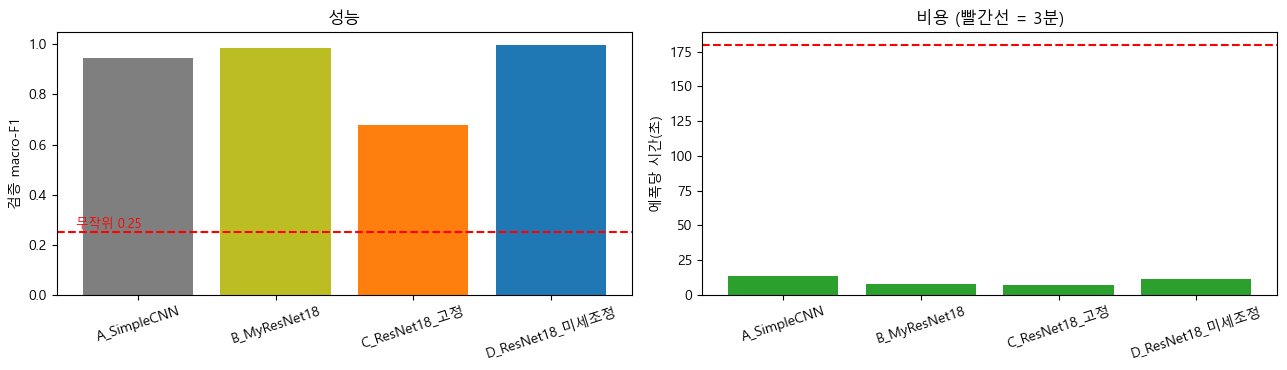

전이학습의 순수 효과 (같은 ResNet18 구조, 사전학습만 다름):
  B(사전학습 없음) → D(사전학습 있음) : macro-F1 +0.0145


In [23]:
t = runs_table()
b = t[t.run_id.isin([r for r, _ in BASE])].set_index('run_id').loc[[r for r, _ in BASE]].reset_index()
display(b[['run_id','params_M','best_epoch','epochs_run','epoch_sec',
           'val_accuracy','val_macro_f1','val_auc']].round(4))

fig, ax = plt.subplots(1, 2, figsize=(13, 3.8))
ax[0].bar(b.run_id, b.val_macro_f1, color=['tab:gray','tab:olive','tab:orange','tab:blue'])
ax[0].axhline(0.25, ls='--', c='r'); ax[0].text(-.45, .27, '무작위 0.25', color='r', fontsize=9)
ax[0].set_ylabel('검증 macro-F1'); ax[0].set_title('성능'); ax[0].tick_params(axis='x', rotation=18)
ax[1].bar(b.run_id, b.epoch_sec, color='tab:green'); ax[1].axhline(EPOCH_BUDGET, ls='--', c='r')
ax[1].set_ylabel('에폭당 시간(초)'); ax[1].set_title('비용 (빨간선 = 3분)'); ax[1].tick_params(axis='x', rotation=18)
plt.tight_layout(); plt.show()

print('전이학습의 순수 효과 (같은 ResNet18 구조, 사전학습만 다름):')
try:
    d = (b.set_index('run_id').loc['D_ResNet18_미세조정','val_macro_f1']
         - b.set_index('run_id').loc['B_MyResNet18','val_macro_f1'])
    print(f'  B(사전학습 없음) → D(사전학습 있음) : macro-F1 {d:+.4f}')
except Exception as e:
    print('  (두 실험이 모두 끝난 뒤 계산된다)')

### 읽는 법

1. **A vs B** — 잔차 연결(3-14)의 효과. 데이터가 1만 장 규모라 아주 깊은 모델이
   반드시 유리하지는 않다. 오히려 B 가 A 보다 나쁠 수도 있는데, 그것도 결과다
   (파라미터가 10배인데 데이터는 그대로이므로 과적합하기 쉽다).
2. **B vs D** — **구조는 같고 사전학습 유무만 다르다.** 이 차이가 전이학습의 순수 이득이다.
   보고서에서 가장 설득력 있는 비교다.
3. **C vs D** — C 가 D 에 크게 못 미치면 "현미경 이미지는 ImageNet 특징으로 표현되지 않는다"는 뜻이고,
   이는 수업 5-3 의 **"도메인이 다르면 미세조정"** 원칙과 일치한다.
4. **에폭당 시간** — C 는 역전파가 헤드에만 흘러 훨씬 빠르다.

> 이 차이들이 **통계적으로 유의한지**는 §19 의 McNemar 검정에서 확인한다. 지금은 "숫자가 다르다"까지만 말한다.

---
# §10. 실험 2 — 에폭을 몇으로 잡을 것인가  🔁

"충분한 에폭"은 감이 아니라 **곡선으로** 정한다.

여기서는 **조기종료를 끄고** 끝까지 돌려서 과적합이 시작되는 지점을 눈으로 확인한다.
(실전에서는 조기종료를 켜지만, 한 번은 전체 모양을 봐야 어디서 멈추는지 알 수 있다)

> **📘 수업 2-9 / 5-4**: 검증 손실이 더 내려가지 않고 **오르기 시작하는 지점**이 과적합 시작점이다.
> 학습 손실은 계속 내려가는데 검증 손실이 오르면 **외우기 시작한 것**이다.

In [24]:
set_seed(42)
tr, va, te = make_loaders('flip', IMAGE_SIZE, BATCH_SIZE, subset=SUBSET)
long_model = build_model('simplecnn', pretrained=False)
LONG_EPOCHS = max(FULL_EPOCHS, 12)
hist_long = train_model(long_model, tr, va, epochs=LONG_EPOCHS, lr=1e-3,
                        patience=LONG_EPOCHS,          # ← 조기종료를 사실상 끈다
                        ckpt_path=f'{RESULT_DIR}/ckpt/epoch_study.pt', label='에폭탐색')

[에폭탐색]  1/15 loss 0.7119 acc 0.7515 | val_loss 0.5163 val_acc 0.7949 val_f1 0.7980 val_auc 0.9674 | lr 1.0e-03 (41s) 저장
[에폭탐색]  2/15 loss 0.3353 acc 0.9010 | val_loss 0.6953 val_acc 0.7355 val_f1 0.7281 val_auc 0.9491 | lr 1.0e-03 (11s) 
[에폭탐색]  3/15 loss 0.2793 acc 0.9146 | val_loss 0.5225 val_acc 0.8135 val_f1 0.8174 val_auc 0.9718 | lr 1.0e-03 (11s) 저장
[에폭탐색]  4/15 loss 0.2252 acc 0.9299 | val_loss 0.4520 val_acc 0.8577 val_f1 0.8587 val_auc 0.9695 | lr 1.0e-03 (11s) 저장
[에폭탐색]  5/15 loss 0.1831 acc 0.9435 | val_loss 0.2498 val_acc 0.9120 val_f1 0.9114 val_auc 0.9923 | lr 1.0e-03 (11s) 저장
[에폭탐색]  6/15 loss 0.1545 acc 0.9473 | val_loss 0.3337 val_acc 0.8683 val_f1 0.8679 val_auc 0.9920 | lr 1.0e-03 (11s) 
[에폭탐색]  7/15 loss 0.1339 acc 0.9559 | val_loss 0.2438 val_acc 0.9025 val_f1 0.9035 val_auc 0.9947 | lr 1.0e-03 (11s) 
[에폭탐색]  8/15 loss 0.1076 acc 0.9647 | val_loss 0.1275 val_acc 0.9663 val_f1 0.9662 val_auc 0.9971 | lr 1.0e-03 (11s) 저장
[에폭탐색]  9/15 loss 0.0908 acc 0.9705 | val_loss

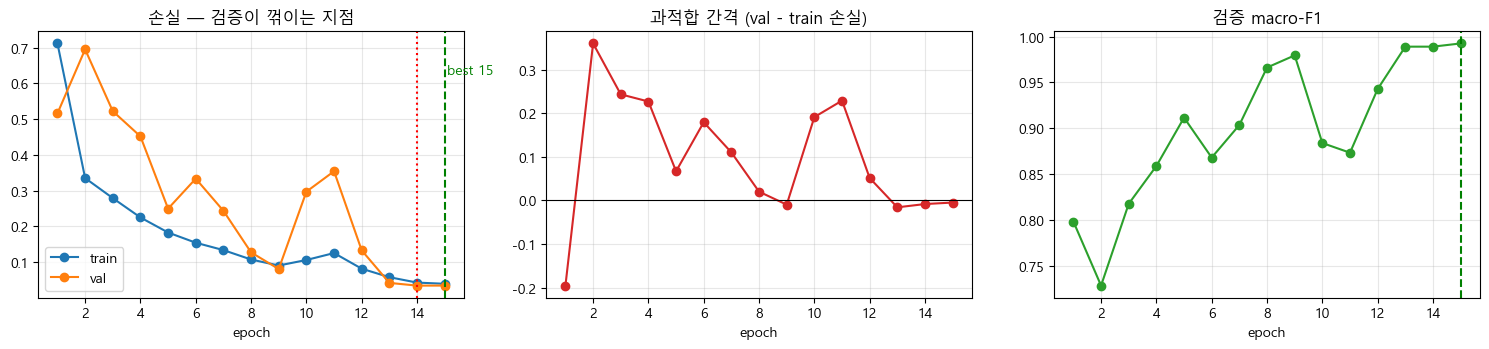

검증 손실 최저   : epoch 14
검증 macro-F1 최고: epoch 15
총 15 에폭 / 에폭당 13초 → 3분 예산 안에서 최대 13 배 여유

결론: best_epoch(15) 가 최대 에폭(15)에 붙어 있으면 아직 덜 학습된 것이므로 epochs 를 늘린다. 한참 앞에서 멈췄으면 그 값이 곧 "충분한 에폭"이다.


In [25]:
e = np.arange(1, len(hist_long['loss']) + 1)
gap = np.array(hist_long['val_loss']) - np.array(hist_long['loss'])
best_e = hist_long['best_epoch']

fig, ax = plt.subplots(1, 3, figsize=(15, 3.6))
ax[0].plot(e, hist_long['loss'], marker='o', label='train')
ax[0].plot(e, hist_long['val_loss'], marker='o', label='val')
ax[0].axvline(best_e, ls='--', c='g'); ax[0].text(best_e+.1, max(hist_long['val_loss'])*.9, f'best {best_e}', color='g')
ax[0].axvline(int(np.argmin(hist_long['val_loss']))+1, ls=':', c='r')
ax[0].set_title('손실 — 검증이 꺾이는 지점'); ax[0].legend(); ax[0].set_xlabel('epoch')
ax[1].plot(e, gap, marker='o', color='tab:red'); ax[1].axhline(0, c='k', lw=.8)
ax[1].set_title('과적합 간격 (val - train 손실)'); ax[1].set_xlabel('epoch')
ax[2].plot(e, hist_long['val_macro_f1'], marker='o', color='tab:green')
ax[2].axvline(best_e, ls='--', c='g'); ax[2].set_title('검증 macro-F1'); ax[2].set_xlabel('epoch')
for a in ax: a.grid(alpha=.3)
plt.tight_layout(); plt.show()

print(f'검증 손실 최저   : epoch {int(np.argmin(hist_long["val_loss"]))+1}')
print(f'검증 macro-F1 최고: epoch {best_e}')
print(f'총 {len(e)} 에폭 / 에폭당 {hist_long["epoch_sec_mean"]:.0f}초 '
      f'→ 3분 예산 안에서 최대 {int(EPOCH_BUDGET*len(e)/max(sum(hist_long["sec"]),1e-9))} 배 여유')
print()
print('결론:', f'best_epoch({best_e}) 가 최대 에폭({len(e)})에 붙어 있으면 아직 덜 학습된 것이므로 '
      'epochs 를 늘린다. 한참 앞에서 멈췄으면 그 값이 곧 "충분한 에폭"이다.')

**이 실험이 정하는 것**

- `FULL_EPOCHS` 를 얼마로 둘지 (곡선이 꺾인 지점 + 여유 몇 에폭)
- `patience` 를 얼마로 둘지 (꺾인 뒤 몇 에폭까지 기다릴지)
- 앞으로의 모든 실험은 **조기종료 + 최적 시점 체크포인트**로 돌리므로,
  `epochs` 는 "최대 허용치"이고 실제 쓰인 값은 **`best_epoch`** 다

---
# §11. 실험 3 — 전처리 비교  🔁

§4 에서 세운 가설을 판정한다. **조건을 하나만 바꾼다** — 모델·학습률·에폭·시드 고정, 전처리만 변경.

In [26]:
REF_MODEL = 'resnet18'
for p in PRESETS:
    run_experiment(f'P_{p}', model_name=REF_MODEL, preset=p, lr=3e-4,
                   epochs=SCREEN_EPOCHS, patience=3, seed=42, subset=SUBSET)
    print('-' * 84)

[건너뜀] P_none — 이미 runs.csv 에 있음
------------------------------------------------------------------------------------
[건너뜀] P_flip — 이미 runs.csv 에 있음
------------------------------------------------------------------------------------
[건너뜀] P_geo — 이미 runs.csv 에 있음
------------------------------------------------------------------------------------
[건너뜀] P_crop — 이미 runs.csv 에 있음
------------------------------------------------------------------------------------
[건너뜀] P_color — 이미 runs.csv 에 있음
------------------------------------------------------------------------------------
[건너뜀] P_crop_geo — 이미 runs.csv 에 있음
------------------------------------------------------------------------------------
[건너뜀] P_strong — 이미 runs.csv 에 있음
------------------------------------------------------------------------------------


,run_id,preset,best_epoch,epoch_sec,val_accuracy,val_macro_f1,val_auc
4,P_none,none,3,10.0,0.9749,0.9749,0.9985
6,P_geo,geo,3,10.0,0.9734,0.9734,0.9987
5,P_flip,flip,3,9.9,0.9713,0.9714,0.9989
8,P_color,color,3,10.4,0.9693,0.9694,0.9988
7,P_crop,crop,3,9.8,0.9548,0.9548,0.9972
10,P_strong,strong,4,10.3,0.9517,0.9518,0.9970
9,P_crop_geo,crop_geo,2,10.2,0.9236,0.9237,0.9923


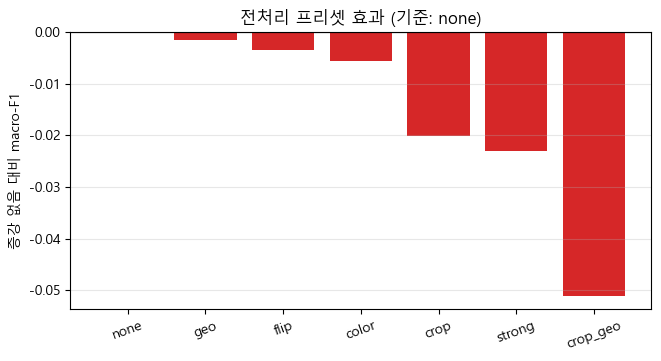

※ none 이 1등이라 §14 비교를 위해 2등 프리셋을 최적으로 삼는다
선정된 전처리: geo


In [27]:
t = runs_table(); pre = t[t.run_id.str.startswith('P_')].sort_values('val_macro_f1', ascending=False)
display(pre[['run_id','preset','best_epoch','epoch_sec','val_accuracy','val_macro_f1','val_auc']].round(4))

base_none = float(pre[pre.preset=='none'].val_macro_f1.iloc[0])
diff = pre.val_macro_f1 - base_none
plt.figure(figsize=(7.5, 3.6))
plt.bar(pre.preset, diff, color=['tab:green' if v > 0 else 'tab:red' for v in diff])
plt.axhline(0, c='k', lw=.8); plt.ylabel('증강 없음 대비 macro-F1'); plt.xticks(rotation=20)
plt.title('전처리 프리셋 효과 (기준: none)'); plt.grid(alpha=.3, axis='y'); plt.show()

BEST_PRESET = str(pre.iloc[0].preset)
if BEST_PRESET == 'none':          # 증강 없음이 1등이면 비교 대상이 사라지므로 2등을 쓴다
    BEST_PRESET = str(pre.iloc[1].preset)
    print('※ none 이 1등이라 §14 비교를 위해 2등 프리셋을 최적으로 삼는다')
print('선정된 전처리:', BEST_PRESET)

### 가설이 맞았는지 확인한다

| 가설 (§4) | 확인 방법 |
|---|---|
| 이미 회전 증강된 데이터다 | `geo`(강한 회전) 가 `flip` 보다 나쁘면 지지됨 |
| 색이 클래스 신호다 | `color`(강한 색 변화) 가 나쁘면 지지됨 |
| 검은 패딩이 방해다 | `crop` 이 좋으면 지지됨 |
| 과한 증강은 짧은 학습에서 불리하다 | `strong` 이 나쁘면 지지됨 |

**예상이 빗나갔다면 그것도 결과다.** 왜 빗나갔는지 쓰는 게 더 좋은 보고서다.

그리고 여기서 나온 1등을 곧바로 "통계적으로 더 좋다"고 말하면 안 된다.
**시드 하나로 한 번씩 돌린 결과**다 → §14 에서 반복하고 §19 에서 검정한다.

---
# §12. 실험 4 — 학습률과 스케줄러  🔁

> **📘 수업 5-3**: 미세조정은 **학습률을 작게**. 사전학습 가중치를 크게 흔들면 배운 걸 잃는다.
> **📘 수업 3-15 / 2-9**: 스케줄러 세 가지 — `StepLR`, `ReduceLROnPlateau`, `CosineAnnealingLR`.

In [28]:
for lr in [1e-3, 5e-4, 3e-4, 1e-4, 5e-5]:
    run_experiment(f'LR_{lr:g}', model_name=REF_MODEL, preset=BEST_PRESET, lr=lr,
                   epochs=SCREEN_EPOCHS, patience=3, seed=42, subset=SUBSET)
    print('-' * 84)

[건너뜀] LR_0.001 — 이미 runs.csv 에 있음
------------------------------------------------------------------------------------
[건너뜀] LR_0.0005 — 이미 runs.csv 에 있음
------------------------------------------------------------------------------------
[건너뜀] LR_0.0003 — 이미 runs.csv 에 있음
------------------------------------------------------------------------------------
[건너뜀] LR_0.0001 — 이미 runs.csv 에 있음
------------------------------------------------------------------------------------
[건너뜀] LR_5e-05 — 이미 runs.csv 에 있음
------------------------------------------------------------------------------------


,run_id,lr,best_epoch,val_accuracy,val_macro_f1,val_loss
15,LR_5e-05,0.00005,4,0.82705,0.82544,0.57554
14,LR_0.0001,0.00010,4,0.94218,0.94223,0.21996
13,LR_0.0003,0.00030,3,0.97335,0.97341,0.08366
12,LR_0.0005,0.00050,3,0.96933,0.96935,0.08405
11,LR_0.001,0.00100,4,0.99397,0.99399,0.02164


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


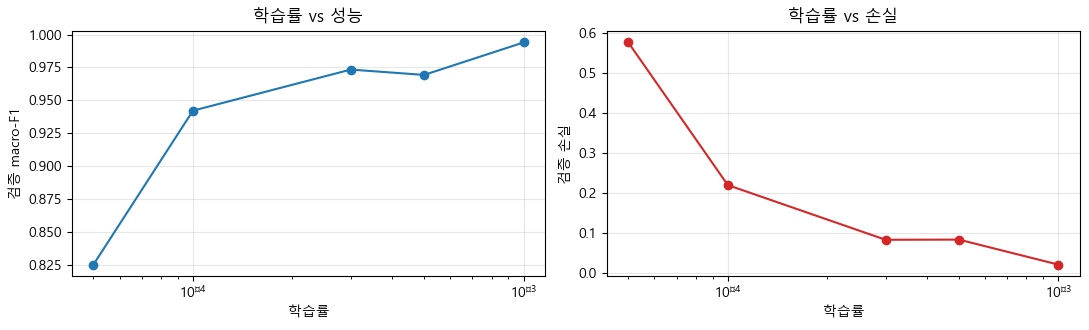

선정된 학습률: 0.001
※ 최적값이 탐색 구간의 양 끝(1e-3 또는 5e-5)이면 구간을 넓혀 다시 돌린다


In [29]:
t = runs_table(); lrt = t[t.run_id.str.startswith('LR_')].sort_values('lr')
display(lrt[['run_id','lr','best_epoch','val_accuracy','val_macro_f1','val_loss']].round(5))

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].semilogx(lrt.lr, lrt.val_macro_f1, marker='o'); ax[0].set_title('학습률 vs 성능')
ax[0].set_xlabel('학습률'); ax[0].set_ylabel('검증 macro-F1')
ax[1].semilogx(lrt.lr, lrt.val_loss, marker='o', color='tab:red'); ax[1].set_title('학습률 vs 손실')
ax[1].set_xlabel('학습률'); ax[1].set_ylabel('검증 손실')
for a in ax: a.grid(alpha=.3)
plt.tight_layout(); plt.show()

BEST_LR = float(lrt.sort_values('val_macro_f1', ascending=False).iloc[0].lr)
print('선정된 학습률:', BEST_LR)
print('※ 최적값이 탐색 구간의 양 끝(1e-3 또는 5e-5)이면 구간을 넓혀 다시 돌린다')

In [30]:
# 수업 3-15 의 스케줄러 3종 비교
for sch in ['plateau', 'cosine', 'step']:
    run_experiment(f'SCH_{sch}', model_name=REF_MODEL, preset=BEST_PRESET, lr=BEST_LR,
                   scheduler=sch, epochs=SCREEN_EPOCHS, patience=3, seed=42, subset=SUBSET)
    print('-' * 84)

t = runs_table(); sch_t = t[t.run_id.str.startswith('SCH_')].sort_values('val_macro_f1', ascending=False)
display(sch_t[['run_id','scheduler','best_epoch','val_accuracy','val_macro_f1','val_loss']].round(5))
BEST_SCH = str(sch_t.iloc[0].scheduler)
print('선정된 스케줄러:', BEST_SCH)

[건너뜀] SCH_plateau — 이미 runs.csv 에 있음
------------------------------------------------------------------------------------
[건너뜀] SCH_cosine — 이미 runs.csv 에 있음
------------------------------------------------------------------------------------
[건너뜀] SCH_step — 이미 runs.csv 에 있음
------------------------------------------------------------------------------------


,run_id,scheduler,best_epoch,val_accuracy,val_macro_f1,val_loss
17,SCH_cosine,cosine,4,0.99598,0.99598,0.01724
16,SCH_plateau,plateau,4,0.99397,0.99399,0.02164
18,SCH_step,step,4,0.98391,0.98393,0.05221


선정된 스케줄러: cosine


---
# §13. 실험 5 — 정규화 · 해상도 · 배치  🔁

> **📘 수업 2-10**: BatchNorm 과 Dropout. 여기서는 헤드의 Dropout 비율을 실험한다.
> weight decay 와 label smoothing 도 같은 목적(과적합 억제)의 손잡이다.

In [31]:
grid = [dict(weight_decay=1e-4, label_smoothing=0.0, dropout=0.0),   # 기준
        dict(weight_decay=1e-2, label_smoothing=0.0, dropout=0.0),
        dict(weight_decay=1e-4, label_smoothing=0.1, dropout=0.0),
        dict(weight_decay=1e-4, label_smoothing=0.0, dropout=0.3),
        dict(weight_decay=1e-2, label_smoothing=0.1, dropout=0.2)]
for i, g in enumerate(grid):
    run_experiment(f'REG_{i}', model_name=REF_MODEL, preset=BEST_PRESET, lr=BEST_LR,
                   scheduler=BEST_SCH, epochs=SCREEN_EPOCHS, patience=3, seed=42, subset=SUBSET, **g)
    print('-' * 84)

t = runs_table(); reg = t[t.run_id.str.startswith('REG_')].sort_values('val_macro_f1', ascending=False)
display(reg[['run_id','weight_decay','label_smoothing','dropout','val_accuracy','val_macro_f1','val_loss']].round(5))
r0 = reg.iloc[0]
BEST_REG = dict(weight_decay=float(r0.weight_decay), label_smoothing=float(r0.label_smoothing),
                dropout=float(r0.dropout))
print('선정된 정규화:', BEST_REG)

[건너뜀] REG_0 — 이미 runs.csv 에 있음
------------------------------------------------------------------------------------
[건너뜀] REG_1 — 이미 runs.csv 에 있음
------------------------------------------------------------------------------------
[건너뜀] REG_2 — 이미 runs.csv 에 있음
------------------------------------------------------------------------------------
[건너뜀] REG_3 — 이미 runs.csv 에 있음
------------------------------------------------------------------------------------
[건너뜀] REG_4 — 이미 runs.csv 에 있음
------------------------------------------------------------------------------------


,run_id,weight_decay,label_smoothing,dropout,val_accuracy,val_macro_f1,val_loss
21,REG_2,0.0001,0.1,0.0,0.99648,0.99649,0.08979
19,REG_0,0.0001,0.0,0.0,0.99598,0.99598,0.01724
23,REG_4,0.0100,0.1,0.2,0.99598,0.99598,0.08875
22,REG_3,0.0001,0.0,0.3,0.99548,0.99548,0.02098
20,REG_1,0.0100,0.0,0.0,0.99397,0.99398,0.01887


선정된 정규화: {'weight_decay': 0.0001, 'label_smoothing': 0.1, 'dropout': 0.0}


[건너뜀] SZ_128 — 이미 runs.csv 에 있음
------------------------------------------------------------------------------------
[건너뜀] SZ_160 — 이미 runs.csv 에 있음
------------------------------------------------------------------------------------
[건너뜀] SZ_224 — 이미 runs.csv 에 있음
------------------------------------------------------------------------------------


,run_id,image_size,epoch_sec,val_accuracy,val_macro_f1
24,SZ_128,128,11.5,0.9965,0.9965
25,SZ_160,160,10.6,0.9950,0.9950
26,SZ_224,224,9.9,0.9965,0.9965


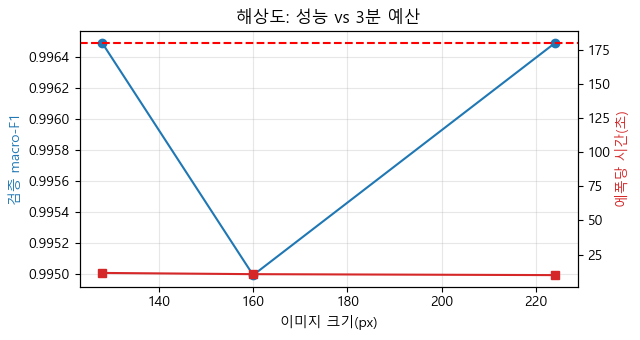

선정된 해상도: 128 (3분 예산을 지키는 것 중 최고 성능)


In [32]:
# 해상도 — 성능과 3분 예산을 동시에 건드리는 손잡이
for size in [128, 160, 224]:
    run_experiment(f'SZ_{size}', model_name=REF_MODEL, preset=BEST_PRESET, image_size=size,
                   lr=BEST_LR, scheduler=BEST_SCH, epochs=SCREEN_EPOCHS, patience=3,
                   seed=42, subset=SUBSET, **BEST_REG)
    print('-' * 84)

t = runs_table(); sz = t[t.run_id.str.startswith('SZ_')].sort_values('image_size')
display(sz[['run_id','image_size','epoch_sec','val_accuracy','val_macro_f1']].round(4))

fig, a1 = plt.subplots(figsize=(6.5, 3.5))
a1.plot(sz.image_size, sz.val_macro_f1, marker='o', color='tab:blue')
a1.set_xlabel('이미지 크기(px)'); a1.set_ylabel('검증 macro-F1', color='tab:blue'); a1.grid(alpha=.3)
a2 = a1.twinx(); a2.plot(sz.image_size, sz.epoch_sec, marker='s', color='tab:red')
a2.axhline(EPOCH_BUDGET, ls='--', c='r'); a2.set_ylabel('에폭당 시간(초)', color='tab:red')
plt.title('해상도: 성능 vs 3분 예산'); plt.tight_layout(); plt.show()

ok_sz = sz[sz.epoch_sec <= EPOCH_BUDGET]
BEST_SIZE = int((ok_sz if len(ok_sz) else sz).sort_values('val_macro_f1', ascending=False).iloc[0].image_size)
print('선정된 해상도:', BEST_SIZE, '(3분 예산을 지키는 것 중 최고 성능)')

In [33]:
# 배치 크기
for bs in [32, 64, 128]:
    try:
        run_experiment(f'BS_{bs}', model_name=REF_MODEL, preset=BEST_PRESET, image_size=BEST_SIZE,
                       batch_size=bs, lr=BEST_LR, scheduler=BEST_SCH, epochs=SCREEN_EPOCHS,
                       patience=3, seed=42, subset=SUBSET, **BEST_REG)
    except RuntimeError as e:
        print(f'bs={bs} 실패(메모리 부족 가능): {str(e)[:70]}')
    print('-' * 84)

t = runs_table(); bst = t[t.run_id.str.startswith('BS_')]
display(bst[['run_id','batch_size','epoch_sec','val_accuracy','val_macro_f1']].round(4))
BEST_BS = int(bst.sort_values('val_macro_f1', ascending=False).iloc[0].batch_size) if len(bst) else BATCH_SIZE
print('선정된 배치:', BEST_BS)

[건너뜀] BS_32 — 이미 runs.csv 에 있음
------------------------------------------------------------------------------------
[건너뜀] BS_64 — 이미 runs.csv 에 있음
------------------------------------------------------------------------------------
[건너뜀] BS_128 — 이미 runs.csv 에 있음
------------------------------------------------------------------------------------


,run_id,batch_size,epoch_sec,val_accuracy,val_macro_f1
27,BS_32,32,12.6,0.9930,0.9930
28,BS_64,64,6.7,0.9965,0.9965
29,BS_128,128,11.4,0.9829,0.9829


선정된 배치: 64


### 후보 모델 재확인 — 3분 예산을 통과한 것들끼리

전처리와 하이퍼파라미터가 정해졌으니, 그 조건에서 백본만 바꿔 다시 비교한다.
**성능 하나가 아니라 성능·시간·비용 대비 이득 셋으로 고른다.**

In [34]:
MODELS = [m for m in ['resnet18','resnet34','efficientnet_b0','mobilenetv3_small_100','resnetv2_50']
          if bool(probe.loc[probe.model == m, 'fits'].max()) or m not in probe.model.values]
print('비교 대상:', MODELS)
for m in MODELS:
    run_experiment(f'M_{m}', model_name=m, preset=BEST_PRESET, image_size=BEST_SIZE,
                   batch_size=BEST_BS, lr=BEST_LR, scheduler=BEST_SCH,
                   epochs=SCREEN_EPOCHS, patience=3, seed=42, subset=SUBSET, **BEST_REG)
    print('-' * 84)

비교 대상: ['resnet18', 'resnet34', 'efficientnet_b0', 'mobilenetv3_small_100', 'resnetv2_50']
[건너뜀] M_resnet18 — 이미 runs.csv 에 있음
------------------------------------------------------------------------------------
[건너뜀] M_resnet34 — 이미 runs.csv 에 있음
------------------------------------------------------------------------------------
[건너뜀] M_efficientnet_b0 — 이미 runs.csv 에 있음
------------------------------------------------------------------------------------
[건너뜀] M_mobilenetv3_small_100 — 이미 runs.csv 에 있음
------------------------------------------------------------------------------------
[건너뜀] M_resnetv2_50 — 이미 runs.csv 에 있음
------------------------------------------------------------------------------------


,run_id,params_M,epoch_sec,best_epoch,val_accuracy,val_macro_f1,val_auc
32,M_efficientnet_b0,4.01,24.1,3,0.9995,0.9995,1.0000
33,M_mobilenetv3_small_100,1.52,21.7,4,0.9970,0.9970,1.0000
30,M_resnet18,11.18,6.5,4,0.9965,0.9965,1.0000
31,M_resnet34,21.29,7.6,4,0.9955,0.9955,1.0000
34,M_resnetv2_50,23.51,15.4,4,0.9950,0.9950,0.9999


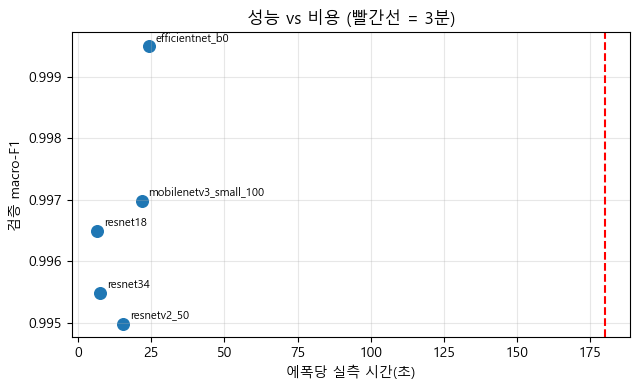

최고 성능 : efficientnet_b0 (macro-F1 0.9995)
최종 선정 : resnet18 (macro-F1 0.9965, 6s, 11.18M)
  이유 1) 3분 예산 준수  2) 최고와 0.5%p 이내  3) 그중 가장 빠름
  → 이 차이가 진짜 없는지는 §19 McNemar 검정으로 확인한다


In [35]:
t = runs_table(); mt = t[t.run_id.str.startswith('M_')].sort_values('val_macro_f1', ascending=False)
display(mt[['run_id','params_M','epoch_sec','best_epoch','val_accuracy','val_macro_f1','val_auc']].round(4))

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.scatter(mt.epoch_sec, mt.val_macro_f1, s=70)
for _, r in mt.iterrows():
    ax.annotate(r.run_id[2:], (r.epoch_sec, r.val_macro_f1), fontsize=8,
                xytext=(5, 4), textcoords='offset points')
ax.axvline(EPOCH_BUDGET, ls='--', c='r'); ax.set_xlabel('에폭당 실측 시간(초)')
ax.set_ylabel('검증 macro-F1'); ax.set_title('성능 vs 비용 (빨간선 = 3분)'); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

cand = mt[mt.epoch_sec <= EPOCH_BUDGET]
top = cand.val_macro_f1.max()
near = cand[cand.val_macro_f1 >= top - 0.005]        # 최고와 0.5%p 이내면 동급으로 본다
pick = near.sort_values('epoch_sec').iloc[0]
BEST_MODEL = pick.run_id[2:]
TOP_MODEL  = mt.iloc[0].run_id[2:]
print(f'최고 성능 : {TOP_MODEL} (macro-F1 {top:.4f})')
print(f'최종 선정 : {BEST_MODEL} (macro-F1 {pick.val_macro_f1:.4f}, {pick.epoch_sec:.0f}s, {pick.params_M}M)')
print('  이유 1) 3분 예산 준수  2) 최고와 0.5%p 이내  3) 그중 가장 빠름')
print('  → 이 차이가 진짜 없는지는 §19 McNemar 검정으로 확인한다')

---
# §14. 실험 6 — 시드를 바꿔 반복  🔁

지금까지의 비교는 **시드 하나짜리 한 번씩**이라, 차이가 설정 때문인지 우연인지 알 수 없다.
같은 설정이라도 초기화와 데이터 순서가 달라지면 점수가 흔들린다.

그래서 비교하고 싶은 두 조건을 **각각 여러 시드로 돌려** 점수쌍을 모은다.
**같은 시드끼리 짝지어야** 전처리 외의 변동이 상쇄된다.

> **H0**: 두 전처리의 검증 macro-F1 평균이 같다
> **H1**: 다르다 (양측)  → §19 의 가설검정 2 에서 판정

In [36]:
AB = {f'A_{BEST_PRESET}': BEST_PRESET, 'B_none': 'none'}
print(f'총 {len(SEEDS)*len(AB)*REPEAT_EPOCHS} 에폭 예정')
for tag, preset in AB.items():
    for s in SEEDS:
        run_experiment(f'SEED_{tag}_s{s}', model_name=BEST_MODEL, preset=preset,
                       image_size=BEST_SIZE, batch_size=BEST_BS, lr=BEST_LR, scheduler=BEST_SCH,
                       epochs=REPEAT_EPOCHS, patience=3, seed=s, subset=SUBSET,
                       verbose=False, **BEST_REG)
        print(f'  {tag} seed={s} 완료')

총 30 에폭 예정
  A_geo seed=0 완료
  A_geo seed=1 완료
  A_geo seed=2 완료
  B_none seed=0 완료
  B_none seed=1 완료
  B_none seed=2 완료


조건,A_최적전처리,B_증강없음
seed,,
0,0.9975,0.9925
1,0.9975,0.9900
2,0.9985,0.9905


조건,A_최적전처리,B_증강없음
mean,0.9978,0.9910
std,0.0006,0.0013


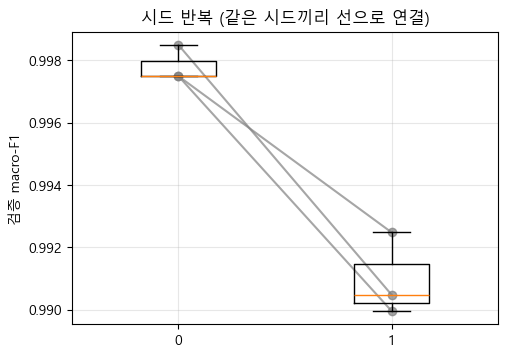

시드별 차이 (A - B): [0.005  0.0075 0.008 ]


In [37]:
t = runs_table(); sd = t[t.run_id.str.startswith('SEED_')].copy()
sd['조건'] = np.where(sd.preset == 'none', 'B_증강없음', 'A_최적전처리')
piv = sd.pivot_table(index='seed', columns='조건', values='val_macro_f1')
display(piv.round(4)); display(piv.describe().round(4).loc[['mean','std']])

plt.figure(figsize=(5.5, 3.8))
for _, r in piv.iterrows():
    plt.plot(['A_최적전처리','B_증강없음'], [r['A_최적전처리'], r['B_증강없음']],
             marker='o', color='gray', alpha=.7)
plt.boxplot([piv['A_최적전처리'], piv['B_증강없음']], positions=[0, 1], widths=.35)
plt.ylabel('검증 macro-F1'); plt.title('시드 반복 (같은 시드끼리 선으로 연결)')
plt.grid(alpha=.3); plt.show()
print('시드별 차이 (A - B):', np.round(piv['A_최적전처리'].values - piv['B_증강없음'].values, 4))

---
# §15. 최종 학습  🔁

지금까지 고른 설정을 모아 **에폭을 충분히 주고** 전체 학습 데이터로 학습한다.
스크리닝에서 쓰던 `SUBSET` 을 풀고, 조기종료가 최적 시점을 잡게 한다.

In [38]:
FINAL_CFG = dict(model_name=BEST_MODEL, preset=BEST_PRESET, image_size=BEST_SIZE,
                 batch_size=BEST_BS, lr=BEST_LR, scheduler=BEST_SCH, **BEST_REG)
print('최종 설정'); print(json.dumps(FINAL_CFG, ensure_ascii=False, indent=1))

final = run_experiment('FINAL', epochs=FULL_EPOCHS, patience=6, seed=42,
                       subset=None,                   # ← 전체 학습 데이터
                       **FINAL_CFG)
if final: plot_history(final['history'], '최종 모델')

t = runs_table(); frow = t[t.run_id == 'FINAL'].iloc[0]
print(f"best_epoch {int(frow.best_epoch)} / 최대 {FULL_EPOCHS}  |  에폭당 {frow.epoch_sec:.0f}초"
      + ('  ⚠ 예산 초과' if frow.epoch_sec > EPOCH_BUDGET else '  ○ 3분 조건 충족'))

최종 설정
{
 "model_name": "resnet18",
 "preset": "geo",
 "image_size": 128,
 "batch_size": 64,
 "lr": 0.001,
 "scheduler": "cosine",
 "weight_decay": 0.0001,
 "label_smoothing": 0.1,
 "dropout": 0.0
}
[건너뜀] FINAL — 이미 runs.csv 에 있음
best_epoch 8 / 최대 15  |  에폭당 5초  ○ 3분 조건 충족


---
# §16. 테스트셋 최종 평가 — **여기서 처음 연다**

지금까지 모든 결정(전처리·모델·학습률·해상도·정규화·배치)은 **검증셋으로만** 했다.
테스트셋을 보면서 고르면 그 점수는 더 이상 "처음 보는 데이터의 성능"이 아니다.

> **📘 수업 5-4 의 사고**: 5장에서 `test_set` 경로에 `'train'` 이 들어가는 바람에
> "테스트 정확도"가 사실은 학습 데이터 점수였다. **분모를 반드시 확인한다.**

In [39]:
def eval_on_test(run_id):
    """저장된 체크포인트를 불러와 테스트셋에서 평가하고 예측을 남긴다(§19 검정용)"""
    t = runs_table(); row = t[t.run_id == run_id].iloc[0]
    model = build_model(str(row['model']), pretrained=False,          # 어차피 덮어쓴다 (수업 5-4)
                        dropout=float(row.get('dropout', 0) or 0),
                        image_size=int(row['image_size']))
    model.load_state_dict(torch.load(f'{RESULT_DIR}/ckpt/{run_id}.pt', map_location=device))
    model = model.to(device)
    _, _, te = make_loaders('none', int(row['image_size']), int(row['batch_size']))
    m = evaluate(model, te, nn.CrossEntropyLoss())
    np.savez_compressed(f'{RESULT_DIR}/preds/{run_id}_TEST.npz',
                        test_probs=m['probs'], test_trues=m['trues'])
    return model, m

final_model, m_test = eval_on_test('FINAL')
print(summarize(m_test, '최종 모델 TEST'))
print(f"  (분모 확인: 테스트 {len(m_test['trues'])}장 — TEST 폴더 장수와 같아야 한다)")

최종 모델 TEST               acc 0.8536  macroF1 0.8579  balanced 0.8537  AUC 0.9444
  (분모 확인: 테스트 2487장 — TEST 폴더 장수와 같아야 한다)


### 신뢰구간을 붙인다

"정확도 0.9832" 는 테스트셋에서 잰 **하나의 추정값**이고 표본이 바뀌면 흔들린다.
**부트스트랩**(테스트셋을 복원추출로 다시 뽑아 반복 측정)으로 그 흔들림의 폭을 잰다.

In [40]:
def bootstrap_ci(y_true, y_pred, metric='accuracy', n_boot=2000, alpha=0.05, seed=42):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    fn = {'accuracy': accuracy_score,
          'macro_f1': lambda a, b: f1_score(a, b, average='macro'),
          'balanced': balanced_accuracy_score}[metric]
    rng = np.random.RandomState(seed); n = len(y_true); vals = []
    for _ in range(n_boot):
        i = rng.randint(0, n, n)
        if len(np.unique(y_true[i])) < 2: continue
        vals.append(fn(y_true[i], y_pred[i]))
    vals = np.array(vals)
    return dict(point=float(fn(y_true, y_pred)),
                lo=float(np.percentile(vals, 100*alpha/2)),
                hi=float(np.percentile(vals, 100*(1-alpha/2))))

for met in ['accuracy', 'macro_f1', 'balanced']:
    ci = bootstrap_ci(m_test['trues'], m_test['preds'], met)
    print(f"  {met:9s} {ci['point']:.4f}   95% 신뢰구간 [{ci['lo']:.4f}, {ci['hi']:.4f}]")

  accuracy  0.8536   95% 신뢰구간 [0.8404, 0.8677]
  macro_f1  0.8579   95% 신뢰구간 [0.8452, 0.8712]
  balanced  0.8537   95% 신뢰구간 [0.8408, 0.8669]


### 혼동행렬과 클래스별 지표

> **📘 수업 4-5**: **정확도만으로는 부족하다.** 정밀도·재현율·AUC 를 함께 본다.
> **📘 수업 5-5**: "어느 실수가 더 비싼가"를 먼저 정하고 지표를 고른다.

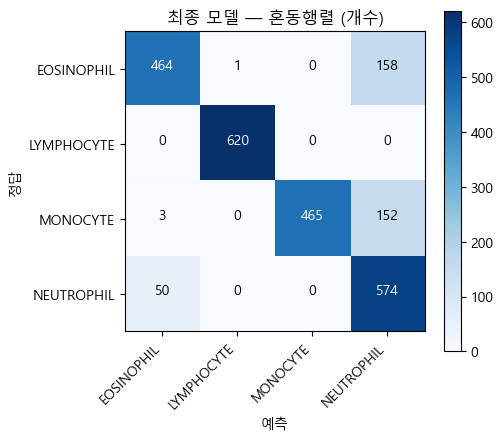

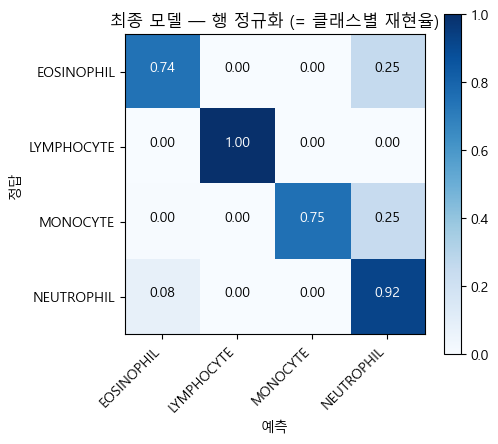

,precision,recall,f1-score,support
EOSINOPHIL,0.8975,0.7448,0.8140,623.0000
LYMPHOCYTE,0.9984,1.0000,0.9992,620.0000
MONOCYTE,1.0000,0.7500,0.8571,620.0000
NEUTROPHIL,0.6493,0.9199,0.7613,624.0000
accuracy,0.8536,0.8536,0.8536,0.8536
macro avg,0.8863,0.8537,0.8579,2487.0000
weighted avg,0.8859,0.8536,0.8577,2487.0000


가장 많이 혼동한 쌍 (정답 → 예측)
  EOSINOPHIL  → NEUTROPHIL  : 158장
  MONOCYTE    → NEUTROPHIL  : 152장
  NEUTROPHIL  → EOSINOPHIL  : 50장
  MONOCYTE    → EOSINOPHIL  : 3장
  EOSINOPHIL  → LYMPHOCYTE  : 1장


In [41]:
cm = plot_confusion(m_test['trues'], m_test['preds'], title='최종 모델 — 혼동행렬 (개수)')
plot_confusion(m_test['trues'], m_test['preds'], normalize=True,
               title='최종 모델 — 행 정규화 (= 클래스별 재현율)')

rep = pd.DataFrame(classification_report(m_test['trues'], m_test['preds'],
                                         target_names=CLASS_NAMES, output_dict=True,
                                         zero_division=0)).T.round(4)
display(rep)

pairs = sorted([(CLASS_NAMES[i], CLASS_NAMES[j], int(cm[i, j]))
                for i in range(NUM_CLASSES) for j in range(NUM_CLASSES) if i != j],
               key=lambda x: -x[2])
print('가장 많이 혼동한 쌍 (정답 → 예측)')
for a, b, n in pairs[:5]: print(f'  {a:11s} → {b:11s} : {n}장')

**의료 문제에서 지표를 고르는 법 (수업 5-5)**

이 문제는 이진 판정이 아니라 4종 감별이라 "재현율이 무조건 중요"라고 말할 수 없다.
대신 이렇게 읽는다.

- **클래스별 재현율**(혼동행렬 대각선) — 어떤 세포를 놓치고 있나
- **EOSINOPHIL ↔ NEUTROPHIL 혼동** — 둘 다 핵이 갈라진 과립구라 형태가 비슷하고,
  구분 근거는 세포질 과립의 색이다. 이 쌍의 오분류가 많다면
  **"색이 중요한 신호"** 라는 §3 의 관찰과 일치하고, §11 에서 강한 색 증강이 불리했던 것도 같은 이유다.
- 실제 진단에 쓴다면 **감별진단에서 어느 오류가 더 비싼지**(예: 백혈병 의심 세포를 정상으로 보는 것)를
  임상적으로 정하고 그에 맞춰 임계값이나 클래스 가중치를 조정해야 한다.

### 오분류 들여다보기 — 수업 3-10

> **📘 수업 3-10**: 틀린 것만 골라 보면 모델의 약점이 보인다.

틀린 것 364장 / 전체 2487장


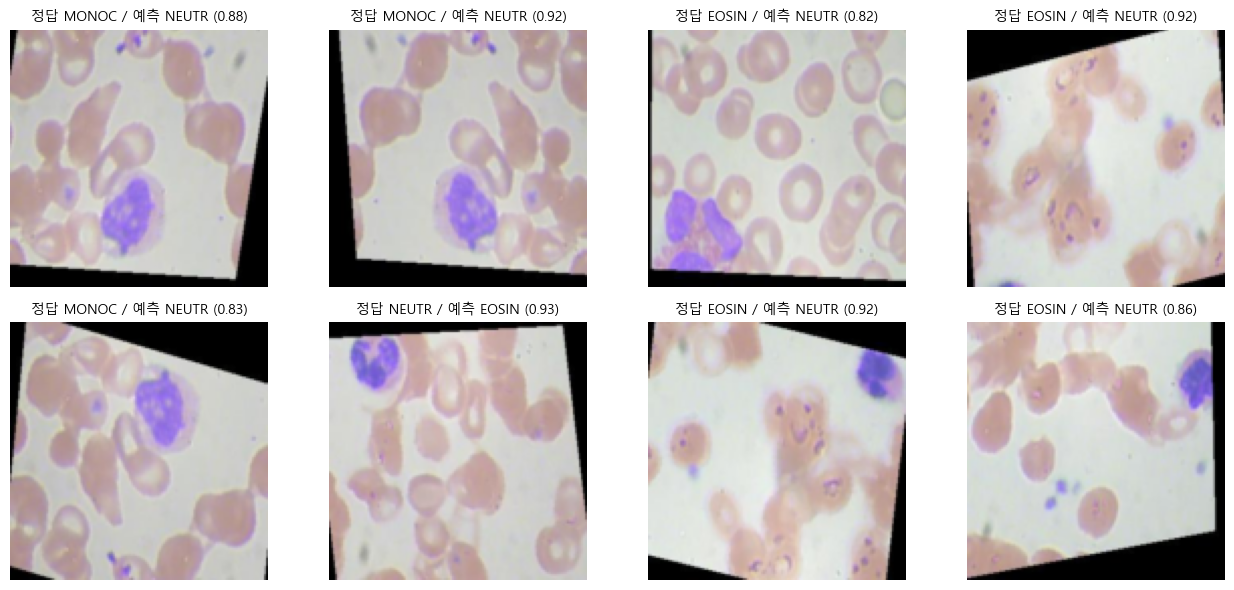

In [42]:
_, ev_tf_final = build_transforms('none', BEST_SIZE)
ds_test = datasets.ImageFolder(os.path.join(DATA_DIR, 'TEST'), transform=ev_tf_final)

wrong = np.where(m_test['preds'] != m_test['trues'])[0]
print(f'틀린 것 {len(wrong)}장 / 전체 {len(m_test["trues"])}장')
if len(wrong):
    sel = np.random.RandomState(0).choice(wrong, min(8, len(wrong)), replace=False)
    fig, axes = plt.subplots(2, 4, figsize=(13, 6)); axes = axes.ravel()
    for ax, i in zip(axes, sel):
        x, y = ds_test[int(i)]; p = m_test['preds'][i]; conf = m_test['probs'][i][p]
        ax.imshow(denorm(x)); ax.axis('off')
        ax.set_title(f'정답 {CLASS_NAMES[y][:5]} / 예측 {CLASS_NAMES[p][:5]} ({conf:.2f})', fontsize=10)
    for ax in axes[len(sel):]: ax.axis('off')
    plt.tight_layout(); plt.show()

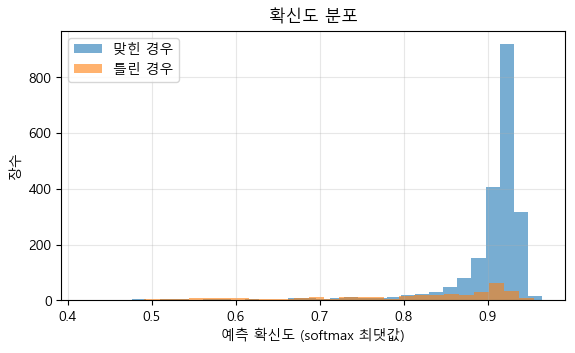

맞힘 평균 확신도 0.899 / 틀림 0.789
틀릴 때 확신도가 낮다면 → "확신 없으면 사람에게 넘긴다"는 운용이 가능하다


In [43]:
# 확신도 분포 — 틀릴 때 모델이 확신하고 있었나?
conf = m_test['probs'].max(1); ok = m_test['preds'] == m_test['trues']
plt.figure(figsize=(6.5, 3.5))
plt.hist(conf[ok], bins=30, alpha=.6, label='맞힌 경우')
plt.hist(conf[~ok], bins=30, alpha=.6, label='틀린 경우')
plt.xlabel('예측 확신도 (softmax 최댓값)'); plt.ylabel('장수'); plt.legend(); plt.grid(alpha=.3)
plt.title('확신도 분포'); plt.show()
print(f'맞힘 평균 확신도 {conf[ok].mean():.3f} / 틀림 {conf[~ok].mean():.3f}')
print('틀릴 때 확신도가 낮다면 → "확신 없으면 사람에게 넘긴다"는 운용이 가능하다')

### 클래스별 ROC 곡선 — 수업 2-8

> **📘 수업 2-8**: ROC 는 이진 분류용이다. 10-클래스 MNIST 에 그대로 쓸 수 없다고 배웠다.
> 다중 분류에서는 **One-vs-Rest** 로 클래스마다 하나씩 그린다.

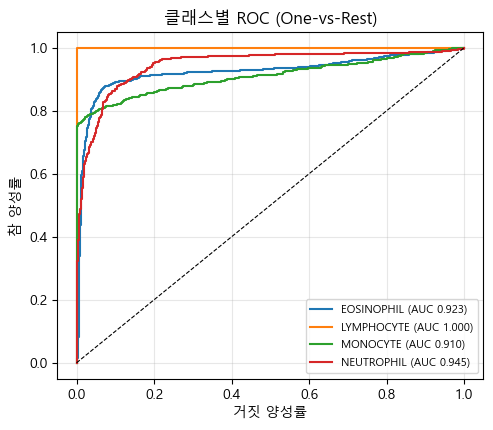

macro 평균 AUC = 0.9444


In [44]:
from sklearn.metrics import roc_curve
plt.figure(figsize=(5.5, 4.5))
for c, name in enumerate(CLASS_NAMES):
    fpr, tpr, _ = roc_curve((m_test['trues'] == c).astype(int), m_test['probs'][:, c])
    plt.plot(fpr, tpr, label=f'{name} (AUC {roc_auc_score((m_test["trues"]==c).astype(int), m_test["probs"][:,c]):.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=.8)
plt.xlabel('거짓 양성률'); plt.ylabel('참 양성률'); plt.title('클래스별 ROC (One-vs-Rest)')
plt.legend(fontsize=8); plt.grid(alpha=.3); plt.show()
print(f"macro 평균 AUC = {m_test['auc']:.4f}")

---
# §17. CAM — 모델은 무엇을 보고 판단했는가

**과제 필수 항목.** 정확도가 높다고 끝이 아니다.
모델이 **배경 적혈구나 검은 패딩 모서리**를 보고 맞히고 있다면 그 정확도는 이 데이터에서만 통한다.

### 원리

우리 모델은 모두 이렇게 끝난다 (§6 에서 그렇게 설계했다).

```
... Conv → 특징맵 f (B, C, h, w) → GAP → Linear(C → 4) → 로짓
```

GAP 는 채널별 공간 평균일 뿐이므로 클래스 $c$ 의 로짓이 이렇게 풀린다.

$$\text{logit}_c=\sum_k w_{c,k}\cdot\frac{1}{hw}\sum_{h,w}f_k(h,w)
=\frac{1}{hw}\sum_{h,w}\underbrace{\sum_k w_{c,k}f_k(h,w)}_{M_c(h,w)}$$

**각 위치가 로짓에 얼마나 기여했는지**가 $M_c(h,w)$ 이고 이것이 CAM 이다.
`GAP → Linear` 구조라 **근사 없이 정확히** 성립한다.

> **📘 수업 3-11 과 이어진다**: 합성곱의 특징맵이 공간 정보를 유지하기 때문에 가능한 일이다.
> 만약 `Flatten → Linear` 로 끝냈다면 위치 정보가 섞여 이렇게 못 뽑는다.

특징맵 격자에서의 CAM 크기: (4, 4) (128px 를 이 격자로 요약한 것)


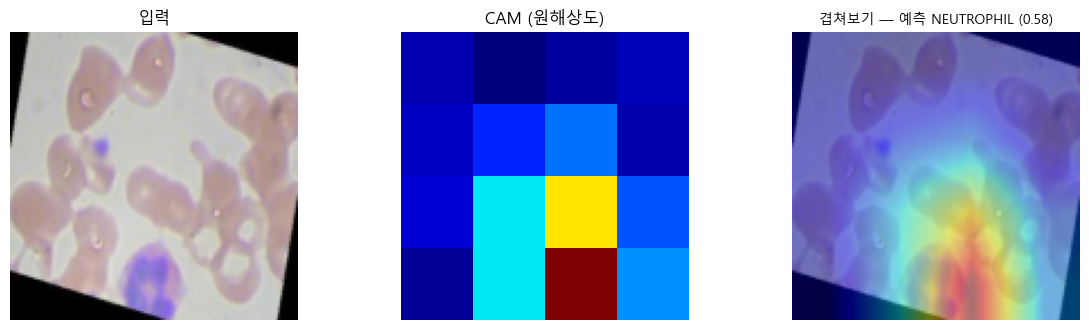

In [45]:
@torch.no_grad()
def cam(model, x, class_idx=None):
    """x: (3,H,W). 반환: (h,w) 히트맵, 예측 클래스, 확률"""
    model.eval()
    x = x.unsqueeze(0).to(device)
    feats  = model.forward_features(x)                 # (1, C, h, w)
    logits = model.head(model.pool(feats).flatten(1))  # (1, 4)
    pred   = int(logits.argmax(1)); c = pred if class_idx is None else class_idx
    w = model.head.weight[c]                           # (C,)  그 클래스의 헤드 가중치
    heat = (feats[0] * w[:, None, None]).sum(0)        # ← 이 한 줄이 CAM
    heat = F.relu(heat)                                # 음의 기여는 버린다
    heat = heat / (heat.max() + 1e-8)
    return heat.cpu().numpy(), pred, torch.softmax(logits, 1)[0].cpu().numpy()


def grad_cam(model, x, class_idx=None):
    """Grad-CAM: 기울기를 채널 가중치로 쓴다. 구조와 무관하게 성립 → CAM 의 검산용"""
    model.eval()
    x = x.unsqueeze(0).to(device)
    feats = model.forward_features(x); feats.retain_grad()
    logits = model.head(model.pool(feats).flatten(1))
    pred = int(logits.argmax(1)); c = pred if class_idx is None else class_idx
    model.zero_grad(set_to_none=True); logits[0, c].backward()
    alpha = feats.grad.mean(dim=(2, 3))[0]             # 공간 평균 = 채널 가중치
    heat = F.relu((feats[0] * alpha[:, None, None]).sum(0))
    heat = heat / (heat.max() + 1e-8)
    return heat.detach().cpu().numpy(), pred


def overlay(ax, x, heat, title='', alpha=0.45):
    img = denorm(x)
    big = F.interpolate(torch.tensor(heat)[None, None], size=img.shape[:2],
                        mode='bilinear', align_corners=False)[0, 0].numpy()
    ax.imshow(img); ax.imshow(big, cmap='jet', alpha=alpha); ax.set_title(title, fontsize=10); ax.axis('off')

x0, y0 = ds_test[0]
heat, pred, prob = cam(final_model, x0)
print('특징맵 격자에서의 CAM 크기:', heat.shape, f'({BEST_SIZE}px 를 이 격자로 요약한 것)')
fig, ax = plt.subplots(1, 3, figsize=(12, 3.4))
ax[0].imshow(denorm(x0)); ax[0].set_title('입력'); ax[0].axis('off')
ax[1].imshow(heat, cmap='jet'); ax[1].set_title('CAM (원해상도)'); ax[1].axis('off')
overlay(ax[2], x0, heat, f'겹쳐보기 — 예측 {CLASS_NAMES[pred]} ({prob[pred]:.2f})')
plt.tight_layout(); plt.show()

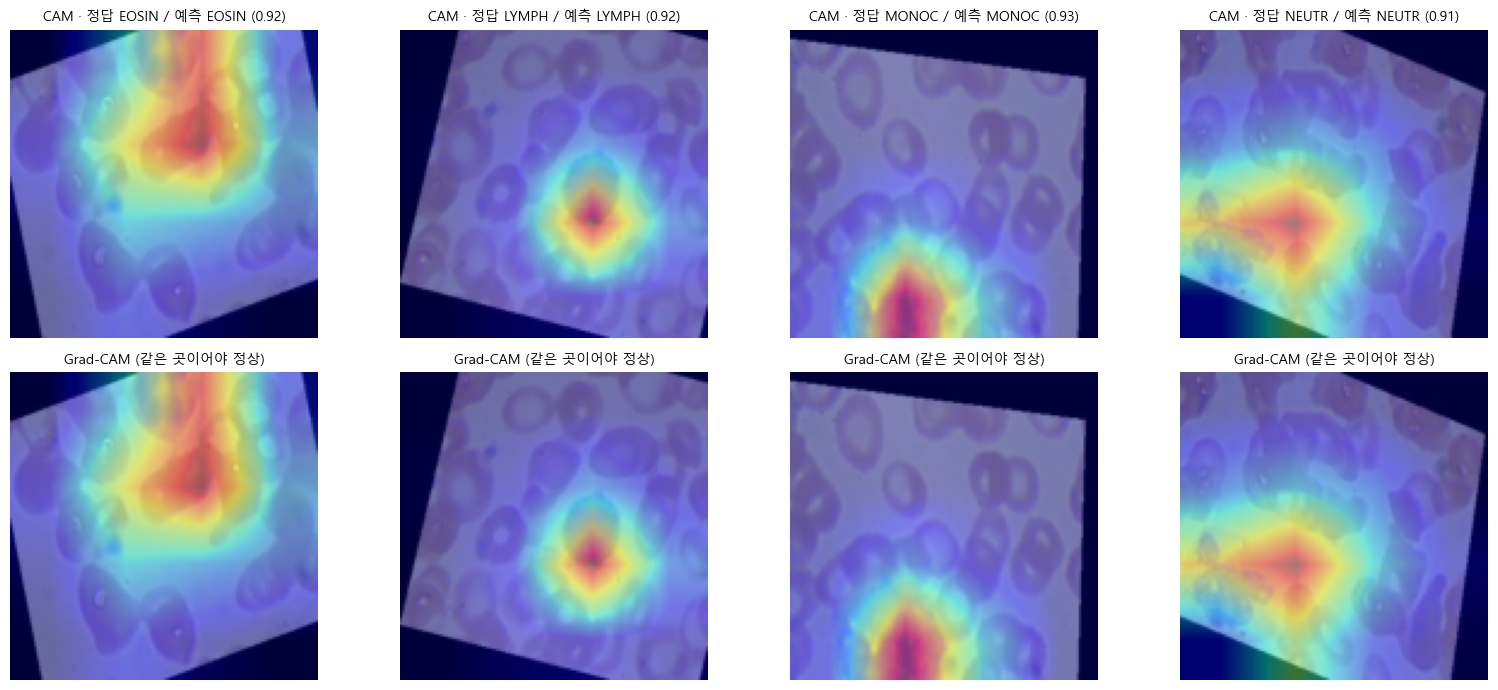

In [46]:
# 클래스별로 맞힌 예시 하나씩
correct = np.where(m_test['preds'] == m_test['trues'])[0]
rng = np.random.RandomState(0)
def pick(c):
    ci = np.where(m_test['trues'] == c)[0]; ok_ = np.intersect1d(correct, ci)
    return int(rng.choice(ok_ if len(ok_) else ci))
idx4 = [pick(c) for c in range(NUM_CLASSES)]

fig, axes = plt.subplots(2, NUM_CLASSES, figsize=(4*NUM_CLASSES, 7))
for k, i in enumerate(idx4):
    x, y = ds_test[i]
    h1, p1, pr = cam(final_model, x); h2, _ = grad_cam(final_model, x)
    overlay(axes[0, k], x, h1, f'CAM · 정답 {CLASS_NAMES[y][:5]} / 예측 {CLASS_NAMES[p1][:5]} ({pr[p1]:.2f})')
    overlay(axes[1, k], x, h2, f'Grad-CAM (같은 곳이어야 정상)')
plt.tight_layout(); plt.show()

CAM 과 Grad-CAM 히트맵 상관계수: 평균 1.000 (1에 가까울수록 일치)


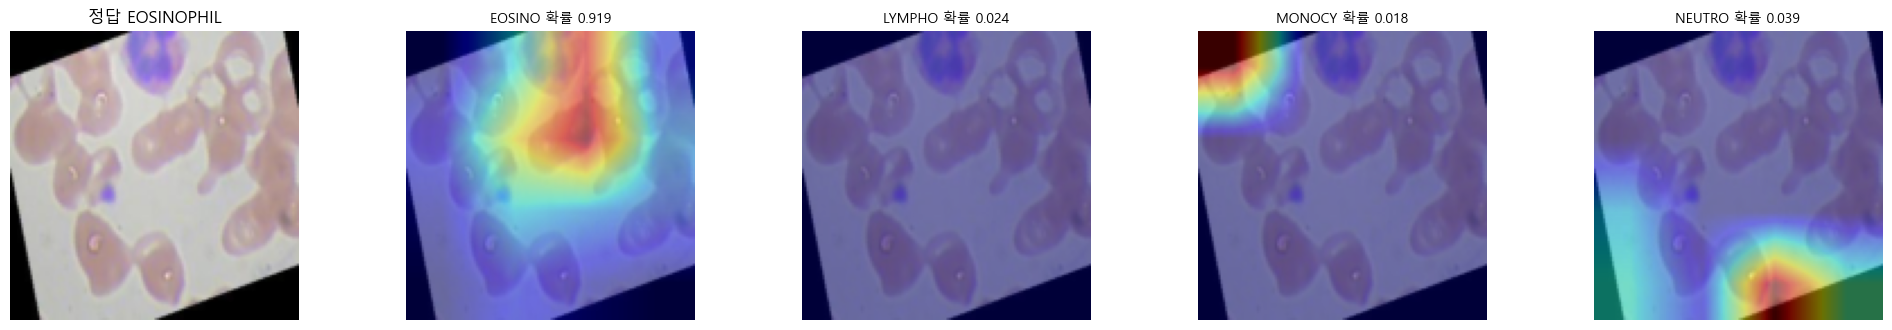

In [47]:
# 두 방법의 일치도를 숫자로 — 시각화 자체가 신뢰할 만한지 확인
cors = []
for i in np.random.RandomState(2).choice(len(ds_test), min(40, len(ds_test)), replace=False):
    x, _ = ds_test[int(i)]
    a, _, _ = cam(final_model, x); b, _ = grad_cam(final_model, x)
    cors.append(np.corrcoef(a.ravel(), b.ravel())[0, 1])
print(f'CAM 과 Grad-CAM 히트맵 상관계수: 평균 {np.nanmean(cors):.3f} (1에 가까울수록 일치)')

# 같은 이미지를 '다른 클래스라고 본다면' — 클래스별 CAM
x, y = ds_test[idx4[0]]
fig, ax = plt.subplots(1, NUM_CLASSES + 1, figsize=(4*(NUM_CLASSES+1), 3.4))
ax[0].imshow(denorm(x)); ax[0].set_title(f'정답 {CLASS_NAMES[y]}'); ax[0].axis('off')
for c in range(NUM_CLASSES):
    h, _, pr = cam(final_model, x, class_idx=c)
    overlay(ax[c+1], x, h, f'{CLASS_NAMES[c][:6]} 확률 {pr[c]:.3f}')
plt.tight_layout(); plt.show()

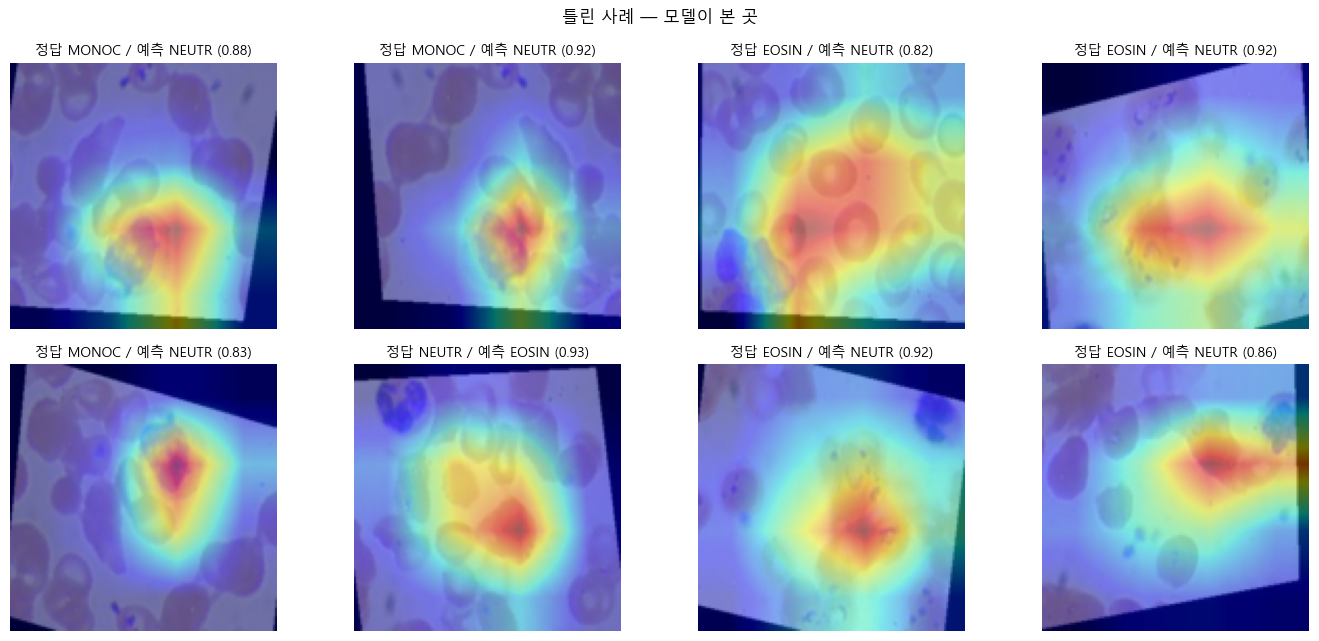

In [48]:
# 틀린 사례의 CAM — 여기가 가장 배울 게 많다
if len(wrong):
    wsel = np.random.RandomState(0).choice(wrong, min(8, len(wrong)), replace=False)
    fig, axes = plt.subplots(2, 4, figsize=(14, 6.5)); axes = axes.ravel()
    for ax_, i in zip(axes, wsel):
        x, y = ds_test[int(i)]; h, p, pr = cam(final_model, x)
        overlay(ax_, x, h, f'정답 {CLASS_NAMES[y][:5]} / 예측 {CLASS_NAMES[p][:5]} ({pr[p]:.2f})')
    for ax_ in axes[len(wsel):]: ax_.axis('off')
    plt.suptitle('틀린 사례 — 모델이 본 곳'); plt.tight_layout(); plt.show()
else:
    print('틀린 사례가 없다')

**틀린 사례에서 볼 전형적 패턴**
- 세포가 프레임 가장자리에 잘려 있다
- 화면에 백혈구가 둘 이상이라 다른 세포를 보고 있다
- 히트맵이 배경으로 흩어져 있다 (근거를 못 찾음)
- **검은 패딩 모서리에 몰려 있다 — 잘못된 단서를 배운 경우, 가장 위험**

### 정량 검증 — "세포를 본다"를 숫자로

눈으로 보는 것은 주관적이다. 측정한다.

1. HSV 에서 **진한 보라색(핵)** 영역 마스크를 만든다 (§3 의 관찰: 핵만 보라, 적혈구는 분홍)
2. CAM 질량 중 마스크 안에 든 비율 $r$ 을 잰다
3. 아무 데나 본다면 $r \approx$ 마스크 **면적 비율** $a$
4. 세포에 집중한다면 $r \gg a$

이 비교가 **§19 의 가설검정 4** 가 된다.

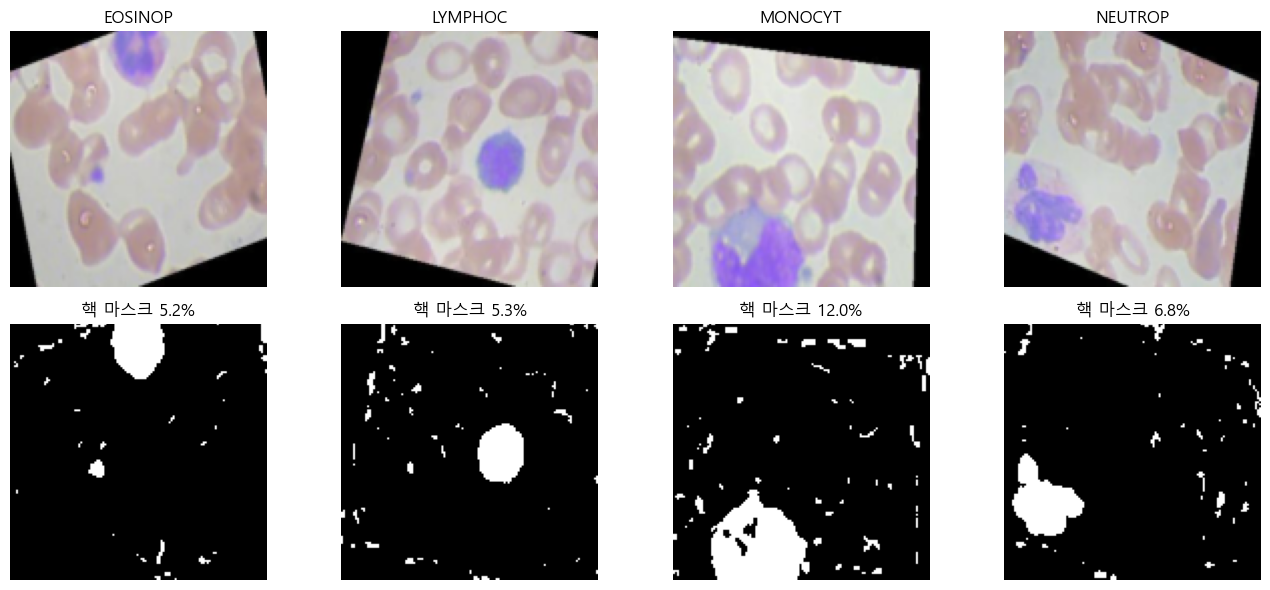

In [49]:
def rgb_to_hsv(img):
    r, g, b = img[..., 0], img[..., 1], img[..., 2]
    mx, mn = img.max(-1), img.min(-1); d = mx - mn + 1e-8
    h = np.where(mx == r, ((g-b)/d) % 6, np.where(mx == g, (b-r)/d + 2, (r-g)/d + 4)) / 6.
    return np.stack([h, np.where(mx > 0, d/(mx+1e-8), 0), mx], -1)

def nucleus_mask(img):
    hsv = rgb_to_hsv(img)
    return ((hsv[..., 0] > 0.60) & (hsv[..., 0] < 0.88) & (hsv[..., 1] > 0.15)).astype(np.float32)

# 마스크가 실제로 핵을 잡는지 눈으로 먼저 확인
fig, axes = plt.subplots(2, NUM_CLASSES, figsize=(3.4*NUM_CLASSES, 6))
for k, i in enumerate(idx4):
    x, y = ds_test[i]; img = denorm(x); mk = nucleus_mask(img)
    axes[0, k].imshow(img); axes[0, k].set_title(CLASS_NAMES[y][:7]); axes[0, k].axis('off')
    axes[1, k].imshow(mk, cmap='gray'); axes[1, k].set_title(f'핵 마스크 {mk.mean()*100:.1f}%'); axes[1, k].axis('off')
plt.tight_layout(); plt.show()

표본 200장
  CAM 질량 중 핵 영역 비율 r : 평균 0.1997
  핵 영역의 면적 비율     a : 평균 0.0800  (아무 데나 볼 때의 기대치)
  집중도 r/a               : 평균 2.38 배


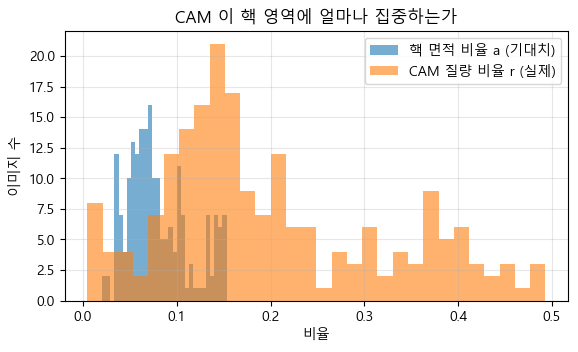

In [50]:
n_sel = min(200, len(ds_test))
sel = np.random.RandomState(1).choice(len(ds_test), n_sel, replace=False)
ratios, areas = [], []
for i in sel:
    x, _ = ds_test[int(i)]
    h, _, _ = cam(final_model, x)
    img = denorm(x); mk = nucleus_mask(img)
    big = F.interpolate(torch.tensor(h)[None, None], size=img.shape[:2],
                        mode='bilinear', align_corners=False)[0, 0].numpy()
    if big.sum() <= 0 or mk.sum() <= 0: continue
    ratios.append(float((big*mk).sum()/big.sum())); areas.append(float(mk.mean()))
ratios, areas = np.array(ratios), np.array(areas)

print(f'표본 {len(ratios)}장')
print(f'  CAM 질량 중 핵 영역 비율 r : 평균 {ratios.mean():.4f}')
print(f'  핵 영역의 면적 비율     a : 평균 {areas.mean():.4f}  (아무 데나 볼 때의 기대치)')
print(f'  집중도 r/a               : 평균 {(ratios/np.maximum(areas,1e-6)).mean():.2f} 배')

plt.figure(figsize=(6.5, 3.5))
plt.hist(areas, bins=30, alpha=.6, label='핵 면적 비율 a (기대치)')
plt.hist(ratios, bins=30, alpha=.6, label='CAM 질량 비율 r (실제)')
plt.xlabel('비율'); plt.ylabel('이미지 수'); plt.legend(); plt.grid(alpha=.3)
plt.title('CAM 이 핵 영역에 얼마나 집중하는가'); plt.show()

> **한계를 분명히 한다**: 이 마스크는 색으로 만든 근사치이지 의학적 분할이 아니다.
> 결론은 **"모델이 배경보다 핵 영역을 유의하게 더 본다"** 까지이고,
> "핵의 분엽 수를 세고 있다"까지는 말하지 않는다. **말할 수 있는 것만 말한다.**

---
# §18. 외부 검증셋 — 증강되지 않은 원본

이 데이터셋은 **원본 366장을 증강해 12,444장으로 불린 것**이다. 그러면 의심할 것이 생긴다.

> 같은 원본에서 나온 사진이 TRAIN 에도 TEST 에도 있으면?
> 모델은 새 데이터가 아니라 **본 적 있는 사진의 회전본**을 맞히는 셈이고,
> 테스트 정확도는 실제 성능보다 부풀려진다.

먼저 픽셀 단위 완전 중복이 있는지 확인하고, 그 다음 **증강 전 원본**으로 다시 평가한다.

In [51]:
# (1) 픽셀 단위 완전 중복 점검 — 32x32 로 줄여 코사인 유사도
def thumb(path, s=32):
    imx = Image.open(path); imx.draft('L', (64, 48))
    a = np.asarray(imx.convert('L').resize((s, s)), dtype=np.float32).ravel()
    a = (a - a.mean()) / (a.std() + 1e-6)
    return a / (np.linalg.norm(a) + 1e-9)

V = {}
for split in ['TRAIN', 'TEST']:
    for c in CLASS_NAMES:
        d = os.path.join(DATA_DIR, split, c)
        V[(split, c)] = np.stack([thumb(os.path.join(d, f)) for f in sorted(os.listdir(d))])
print('같은 클래스 안에서 TEST 각 장의 최근접 TRAIN 유사도')
for c in CLASS_NAMES:
    A, B = V[('TRAIN', c)], V[('TEST', c)]
    best = np.concatenate([(B[i:i+256] @ A.T).max(1) for i in range(0, len(B), 256)])
    print(f'  {c:11s} 중앙값 {np.median(best):.3f} | >0.99 {(best>0.99).mean()*100:4.1f}% | >0.95 {(best>0.95).mean()*100:4.1f}%')
A = np.concatenate([V[('TRAIN', c)] for c in CLASS_NAMES[1:]]); B = V[('TEST', CLASS_NAMES[0])]
best = np.concatenate([(B[i:i+256] @ A.T).max(1) for i in range(0, len(B), 256)])
print(f'  [대조군] {CLASS_NAMES[0]} TEST vs 다른 클래스 TRAIN : 중앙값 {np.median(best):.3f}')

같은 클래스 안에서 TEST 각 장의 최근접 TRAIN 유사도
  EOSINOPHIL  중앙값 0.894 | >0.99  0.0% | >0.95  0.3%
  LYMPHOCYTE  중앙값 0.890 | >0.99  0.0% | >0.95  0.2%
  MONOCYTE    중앙값 0.896 | >0.99  0.0% | >0.95  0.3%
  NEUTROPHIL  중앙값 0.897 | >0.99  0.0% | >0.95  0.6%
  [대조군] EOSINOPHIL TEST vs 다른 클래스 TRAIN : 중앙값 0.906


**결론과 한계 (보고서에 그대로 쓸 것)**

- 유사도 0.99 초과가 사실상 0% → **복사-붙여넣기 수준의 완전 중복은 없다**
- 그런데 **대조군(다른 클래스)의 유사도가 같은 클래스와 거의 같다** → 이 지표는 클래스를 구분하는 힘이 없고,
  따라서 **회전·이동된 형제 이미지까지 잡아내지는 못한다**
- 즉 **원본 단위 분리는 보장되지 않는다**

그래서 **증강 전 원본**으로 한 번 더 재고, 두 값이 통계적으로 다른지 §19 가설검정 3 에서 판정한다.

In [52]:
# (2) 원본 366장을 ImageFolder 형식으로 정리 (라벨이 하나뿐인 것, 4클래스만)
EXT_DIR = './external'
lab = pd.read_csv(os.path.join(ORIG_DIR, 'labels.csv'))
if lab.shape[1] == 3: lab.columns = ['idx', 'Image', 'Category']
lab = lab.dropna(subset=['Category']); lab['Category'] = lab['Category'].str.strip()
single = lab[lab['Category'].isin(CLASS_NAMES)]

if os.path.isdir(EXT_DIR): shutil.rmtree(EXT_DIR)
cnt = collections.Counter()
for _, r in single.iterrows():
    src = os.path.join(ORIG_DIR, 'JPEGImages', f'BloodImage_{int(r["Image"]):05d}.jpg')
    if not os.path.exists(src): continue
    dd = os.path.join(EXT_DIR, r['Category']); os.makedirs(dd, exist_ok=True)
    shutil.copy(src, os.path.join(dd, os.path.basename(src))); cnt[r['Category']] += 1
print('외부 검증셋:', dict(cnt), '총', sum(cnt.values()), '장')
print('제외:', len(lab) - len(single), '장 (복수 라벨 / BASOPHIL)')

외부 검증셋: {'NEUTROPHIL': 206, 'EOSINOPHIL': 88, 'MONOCYTE': 20, 'LYMPHOCYTE': 33} 총 347 장
제외: 18 장 (복수 라벨 / BASOPHIL)


원본(외부) 평가                acc 0.9135  macroF1 0.9258  balanced 0.9281  AUC 0.9869


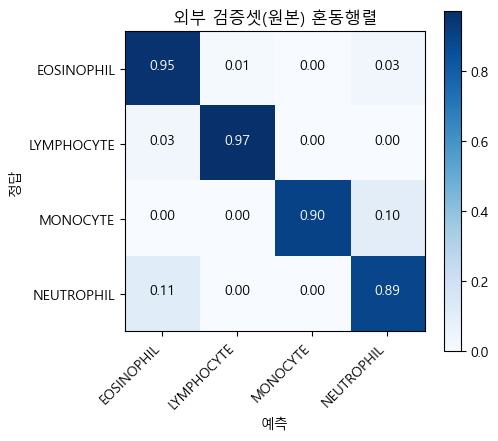

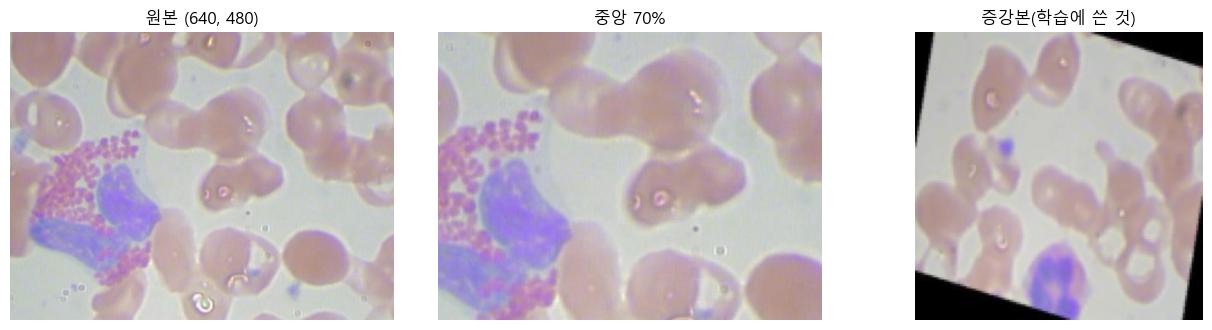

In [53]:
# 원본은 640x480 으로 시야가 넓다 → 중앙 70% 를 잘라 화각을 맞춘다
ext_tf = transforms.Compose([
    transforms.Lambda(lambda p: transforms.functional.center_crop(
        p, [int(p.size[1]*0.7), int(p.size[0]*0.7)])),
    transforms.Resize((BEST_SIZE, BEST_SIZE)), transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)])
ext_ds = datasets.ImageFolder(EXT_DIR, transform=ext_tf)
ext_loader = DataLoader(ext_ds, batch_size=64, shuffle=False, num_workers=0)

m_ext = evaluate(final_model, ext_loader, nn.CrossEntropyLoss())
print(summarize(m_ext, '원본(외부) 평가'))
plot_confusion(m_ext['trues'], m_ext['preds'], normalize=True, title='외부 검증셋(원본) 혼동행렬')

fig, ax = plt.subplots(1, 3, figsize=(13, 3.4))
o = Image.open(sorted(glob.glob(os.path.join(EXT_DIR, '*', '*.jpg')))[0]).convert('RGB')
w_, h_ = o.size
ax[0].imshow(o); ax[0].set_title(f'원본 {o.size}'); ax[0].axis('off')
ax[1].imshow(o.crop((int(w_*.15), int(h_*.15), int(w_*.85), int(h_*.85)))); ax[1].set_title('중앙 70%'); ax[1].axis('off')
ax[2].imshow(denorm(ds_test[0][0])); ax[2].set_title('증강본(학습에 쓴 것)'); ax[2].axis('off')
plt.tight_layout(); plt.show()

---
# §19. 가설검정

**과제 필수 항목.** 중요한 건 "검정을 했다"가 아니라 **"이 상황에 왜 이 검정인가"** 를 설명하는 것이다.

### 검정을 고르는 기준

```
비교하려는 두 값이 같은 대상에서 나왔나?
 ├─ 예 (짝지은 자료) ─┬─ 이진 결과(맞음/틀림) → McNemar
 │                    └─ 연속값(점수)         → 대응표본 t검정 / 윌콕슨
 └─ 아니오 (독립 표본) ┬─ 비율 비교           → 두 비율 z검정
                       └─ 평균 비교           → 독립표본 t검정
```

**같은 테스트셋을 쓴 두 모델을 독립표본 검정으로 비교하는 것이 가장 흔한 실수다.**
같은 이미지들이므로 두 결과는 강하게 연관돼 있고, 그 연관을 무시하면 검정력을 잃는다.

| # | 질문 | H0 | H1 | 검정 |
|---|---|---|---|---|
| 1 | 전이학습이 밑바닥 CNN보다 나은가 | 두 모델의 오분류율이 같다 | 다르다 | **McNemar** |
| 2 | 전처리가 효과가 있는가 | 두 조건의 평균 macro-F1 이 같다 | 다르다 | **대응표본 t + 윌콕슨** |
| 3 | 이 테스트 점수를 믿어도 되는가 | 증강 TEST 정확도 = 원본 정확도 | 다르다 | **두 비율 z검정** |
| 4 | CAM 이 세포를 보는가 | CAM 질량비 = 면적비 | 질량비가 더 크다 | **대응표본 t (단측)** |

유의수준 α = 0.05. 검정을 4번 하므로 마지막에 **Holm 보정**을 한다.

## 검정 1 — 전이학습 vs 밑바닥 CNN (McNemar)

두 모델의 결과를 2×2 표로 정리한다.

| | B 맞음 | B 틀림 |
|---|---|---|
| **A 맞음** | n₁₁ | **b** |
| **A 틀림** | **c** | n₀₀ |

둘 다 맞히거나 둘 다 틀린 칸은 **두 모델을 구분하는 정보가 없다.**
차이는 오직 **b 와 c** 에 있고, H0 가 참이면 $b\sim\text{Binom}(b+c,\,0.5)$ 이다.

In [54]:
ALPHA = 0.05
_, m_base = eval_on_test('A_SimpleCNN')
print(summarize(m_test, '최종(전이학습) TEST')); print(summarize(m_base, '밑바닥 CNN TEST'))

y = m_test['trues']
A_ok = (m_test['preds'] == y)      # A = 전이학습
B_ok = (m_base['preds'] == y)      # B = 밑바닥
n11 = int((A_ok & B_ok).sum()); b = int((A_ok & ~B_ok).sum())
c_  = int((~A_ok & B_ok).sum()); n00 = int((~A_ok & ~B_ok).sum())
display(pd.DataFrame([[n11, b], [c_, n00]], index=['A(전이학습) 맞음','A 틀림'],
                     columns=['B(밑바닥) 맞음','B 틀림']))
print(f'불일치 칸: b={b} (A만 맞힘), c={c_} (B만 맞힘), 합 {b+c_}')

최종(전이학습) TEST            acc 0.8536  macroF1 0.8579  balanced 0.8537  AUC 0.9444
밑바닥 CNN TEST             acc 0.8745  macroF1 0.8765  balanced 0.8746  AUC 0.9745


,B(밑바닥) 맞음,B 틀림
A(전이학습) 맞음,2056,67
A 틀림,119,245


불일치 칸: b=67 (A만 맞힘), c=119 (B만 맞힘), 합 186


In [55]:
def mcnemar_test(y_true, pred_a, pred_b):
    a_ok = (np.asarray(pred_a) == np.asarray(y_true)); b_ok = (np.asarray(pred_b) == np.asarray(y_true))
    n01 = int((a_ok & ~b_ok).sum()); n10 = int((~a_ok & b_ok).sum()); n = n01 + n10
    if n == 0:
        stat, p, meth = 0.0, 1.0, '불일치 없음'
    elif n < 25:                                   # 표본이 작으면 정확 이항검정
        stat = float(min(n01, n10)); p = float(stats.binomtest(min(n01, n10), n, 0.5).pvalue)
        meth = '정확 이항검정'
    else:                                          # 크면 연속성 보정 카이제곱
        stat = (abs(n01 - n10) - 1)**2 / n; p = float(stats.chi2.sf(stat, df=1))
        meth = '카이제곱(연속성 보정)'
    return dict(b=n01, c=n10, n_disc=n, statistic=float(stat), p_value=p, method=meth,
                acc_A=float(a_ok.mean()), acc_B=float(b_ok.mean()), diff=float(a_ok.mean()-b_ok.mean()))

r1 = mcnemar_test(y, m_test['preds'], m_base['preds'])
print('=== 검정 1: McNemar ===')
print('  H0: 두 모델의 오분류율이 같다   H1: 다르다 (양측)')
print(f"  {r1['method']}  통계량 {r1['statistic']:.4f}  p = {r1['p_value']:.4e}")
print(f"  정확도 {r1['acc_A']:.4f} (전이학습) vs {r1['acc_B']:.4f} (밑바닥)  차이 {r1['diff']:+.4f}")
print('  판정:', 'H0 기각 → 두 모델의 성능은 통계적으로 다르다' if r1['p_value'] < ALPHA
      else 'H0 기각 못함 → 차이를 입증하지 못했다')

# 검산: 순열검정 (분포 가정이 없는 대안)
d_ = A_ok.astype(int) - B_ok.astype(int); obs = d_.mean()
rngp = np.random.RandomState(0)
null = np.array([(d_ * rngp.choice([-1, 1], len(d_))).mean() for _ in range(5000)])
print(f"  [검산] 순열검정 p = {(np.abs(null) >= abs(obs)-1e-12).mean():.4f}")

=== 검정 1: McNemar ===
  H0: 두 모델의 오분류율이 같다   H1: 다르다 (양측)
  카이제곱(연속성 보정)  통계량 13.9839  p = 1.8439e-04
  정확도 0.8536 (전이학습) vs 0.8745 (밑바닥)  차이 -0.0209
  판정: H0 기각 → 두 모델의 성능은 통계적으로 다르다
  [검산] 순열검정 p = 0.0004


In [56]:
# (선택) 최고 성능 모델과 최종 선정 모델의 차이가 유의하지 않음을 보인다
if TOP_MODEL != BEST_MODEL and already_run(f'M_{TOP_MODEL}'):
    _, m_top = eval_on_test(f'M_{TOP_MODEL}')
    rx = mcnemar_test(y, m_test['preds'], m_top['preds'])
    print(f"최종({BEST_MODEL}) vs 최고성능({TOP_MODEL}) : "
          f"{rx['acc_A']:.4f} vs {rx['acc_B']:.4f}, p = {rx['p_value']:.4f}")
    print('  →', '차이 없음 → 더 싼 모델을 쓴 것이 정당하다' if rx['p_value'] >= ALPHA
          else '차이 있음 → 성능이 더 중요하면 최고 모델을 재검토한다')
else:
    print('최고 성능 모델이 곧 최종 모델이라 추가 비교 생략')

최종(resnet18) vs 최고성능(efficientnet_b0) : 0.8536 vs 0.8725, p = 0.0001
  → 차이 있음 → 성능이 더 중요하면 최고 모델을 재검토한다


## 검정 2 — 전처리 효과 (대응표본 t검정 + 윌콕슨)

§14 에서 모은 시드별 점수쌍을 쓴다. **같은 시드끼리 짝지어야** 전처리 외의 변동이 상쇄된다.

**p값만 보면 안 된다.** 표본이 몇 쌍뿐이라 검정력이 낮고, 반대로 분산이 작으면
사소한 차이도 유의해진다. → **효과크기(Cohen's d)와 차이의 신뢰구간**을 함께 본다.

In [57]:
a_col = [c for c in piv.columns if c.startswith('A_')][0]
b_col = [c for c in piv.columns if c.startswith('B_')][0]
a_s, b_s = piv[a_col].values, piv[b_col].values
d = a_s - b_s
t_stat, p_t = stats.ttest_rel(a_s, b_s)
try:    w_stat, p_w = stats.wilcoxon(a_s, b_s)
except ValueError: w_stat, p_w = float('nan'), float('nan')
sd_ = d.std(ddof=1); ci = (d.mean()-1.96*sd_/np.sqrt(len(d)), d.mean()+1.96*sd_/np.sqrt(len(d)))

print('=== 검정 2: 대응표본 검정 (최적 전처리 vs 증강 없음) ===')
print('  H0: 두 조건의 평균 macro-F1 이 같다   H1: 다르다 (양측)')
print(f'  n = {len(d)}쌍   평균 {a_s.mean():.4f} vs {b_s.mean():.4f}   차이 {d.mean():+.4f}')
print(f'  차이의 95% 신뢰구간 [{ci[0]:+.4f}, {ci[1]:+.4f}]')
print(f'  대응표본 t : t = {t_stat:.3f}, p = {p_t:.4f}')
print(f'  윌콕슨     : W = {w_stat:.1f}, p = {p_w:.4f}  (정규성 가정이 약한 대안)')
cohen_d = d.mean()/sd_ if sd_ > 0 else float('nan')
print(f"  효과크기 Cohen's d = {cohen_d:.2f} "
      f"({'큼' if abs(cohen_d)>0.8 else '중간' if abs(cohen_d)>0.5 else '작음'})")
print('  판정:', 'H0 기각 → 전처리가 성능에 영향을 준다' if p_t < ALPHA
      else 'H0 기각 못함 → 이 자료로는 차이를 입증하지 못했다')

=== 검정 2: 대응표본 검정 (최적 전처리 vs 증강 없음) ===
  H0: 두 조건의 평균 macro-F1 이 같다   H1: 다르다 (양측)
  n = 3쌍   평균 0.9978 vs 0.9910   차이 +0.0068
  차이의 95% 신뢰구간 [+0.0050, +0.0087]
  대응표본 t : t = 7.363, p = 0.0180
  윌콕슨     : W = 0.0, p = 0.2500  (정규성 가정이 약한 대안)
  효과크기 Cohen's d = 4.25 (큼)
  판정: H0 기각 → 전처리가 성능에 영향을 준다


> **"기각 못 함"은 "같다"가 아니다.** 귀무가설은 채택하는 것이 아니라 기각하지 못하는 것이다.
> 표본이 작으면 실제 차이가 있어도 못 잡는다.
> → **"차이가 없다"가 아니라 "이 자료로는 차이를 입증하지 못했다"** 로 쓴다.
> 결론을 더 확실히 하려면 `SEEDS` 를 10~20개로 늘린다.

## 검정 3 — 이 테스트 점수를 믿어도 되는가 (두 비율 z검정) ⭐

**이 프로젝트에서 가장 중요한 검정.** §18 에서 만든 원본 평가와 비교한다.
두 평가셋은 **서로 다른 표본**이므로 McNemar 가 아니라 두 비율 검정을 쓴다.

$$z=\frac{\hat p_1-\hat p_2}{\sqrt{\hat p(1-\hat p)(1/n_1+1/n_2)}},\quad \hat p=\frac{k_1+k_2}{n_1+n_2}$$

=== 검정 3: 두 비율 z검정 ===
  H0: 두 평가셋의 정확도가 같다   H1: 다르다 (양측)
  증강 TEST : 2123/2487 = 0.8536
  원본      : 317/347 = 0.9135
  차이 -0.0599  95% 신뢰구간 [-0.0926, -0.0272]
  z = -3.022   p = 2.5149e-03
  판정: H0 기각 → 두 값이 통계적으로 다르다


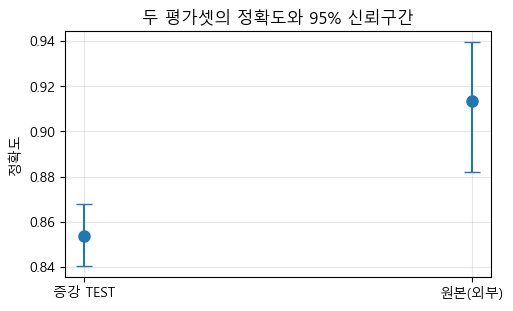

In [58]:
k1 = int((m_test['preds'] == m_test['trues']).sum()); n1 = len(m_test['trues'])
k2 = int((m_ext['preds']  == m_ext['trues']).sum());  n2 = len(m_ext['trues'])
p1, p2 = k1/n1, k2/n2
p_pool = (k1+k2)/(n1+n2)
se = math.sqrt(p_pool*(1-p_pool)*(1/n1 + 1/n2))
z = (p1-p2)/se if se > 0 else 0.0
p3 = float(2*stats.norm.sf(abs(z)))
se_d = math.sqrt(p1*(1-p1)/n1 + p2*(1-p2)/n2)

print('=== 검정 3: 두 비율 z검정 ===')
print('  H0: 두 평가셋의 정확도가 같다   H1: 다르다 (양측)')
print(f'  증강 TEST : {k1}/{n1} = {p1:.4f}')
print(f'  원본      : {k2}/{n2} = {p2:.4f}')
print(f'  차이 {p1-p2:+.4f}  95% 신뢰구간 [{p1-p2-1.96*se_d:+.4f}, {p1-p2+1.96*se_d:+.4f}]')
print(f'  z = {z:.3f}   p = {p3:.4e}')
print('  판정:', 'H0 기각 → 두 값이 통계적으로 다르다' if p3 < ALPHA else 'H0 기각 못함')

ci_t = bootstrap_ci(m_test['trues'], m_test['preds'], 'accuracy')
ci_e = bootstrap_ci(m_ext['trues'],  m_ext['preds'],  'accuracy')
plt.figure(figsize=(5.5, 3.2))
plt.errorbar([0, 1], [ci_t['point'], ci_e['point']],
             yerr=[[ci_t['point']-ci_t['lo'], ci_e['point']-ci_e['lo']],
                   [ci_t['hi']-ci_t['point'], ci_e['hi']-ci_e['point']]], fmt='o', capsize=6, ms=8)
plt.xticks([0, 1], ['증강 TEST', '원본(외부)']); plt.ylabel('정확도')
plt.title('두 평가셋의 정확도와 95% 신뢰구간'); plt.grid(alpha=.3); plt.show()

### 해석 지침 — 결과에 따라 이렇게 쓴다

**H0 기각 + 원본 정확도가 낮다면** → 증강 TEST 점수는 실제 일반화 성능을 **과대평가**한 것이다.
두 숫자를 **모두** 적고 "보수적 추정치는 원본 쪽"이라고 쓴다.

**H0 기각 못했다면** → "누수가 없다"가 아니라 **"과대추정의 증거를 찾지 못했다"** 로 쓴다.

**어느 쪽이든 함께 적을 것 — 혼입요인**
1. 원본은 640×480 전체 시야라 세포가 여러 개일 수 있어 **문제 자체가 더 어렵다**
   → 차이 전부를 누수 탓으로 돌릴 수 없다
2. 원본 표본이 작아 **검정력이 제한**된다
3. 중앙 70% 자르기로 화각을 맞췄지만 완전히 같지는 않다

> 채점자가 "정확도 99%면 너무 높지 않나요?" 라고 물었을 때
> **"저희도 그렇게 봐서 검사했고, 여기까지가 말할 수 있는 범위입니다"** 라고 답할 수 있다.

## 검정 4 — CAM 이 실제로 세포를 보는가 (단측 대응표본 t검정)

같은 이미지에서 두 값(CAM 질량비 r, 면적비 a)을 재므로 **대응표본**이다.
"더 큰가"만 궁금하므로 **단측**검정을 쓴다.

=== 검정 4: 대응표본 t검정 (단측) ===
  H0: CAM 질량비 = 면적비   H1: CAM 질량비가 더 크다
  n = 200장   r 평균 0.1997   a 평균 0.0800
  평균 차이 +0.1197   t = 18.458   p = 2.7281e-45
  효과크기 Cohen's d = 1.31
  판정: H0 기각 → CAM 은 핵 영역에 유의하게 집중한다


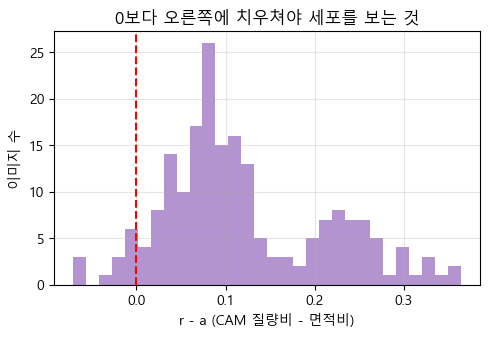

In [59]:
t4, p4 = stats.ttest_rel(ratios, areas, alternative='greater')
dd = ratios - areas
print('=== 검정 4: 대응표본 t검정 (단측) ===')
print('  H0: CAM 질량비 = 면적비   H1: CAM 질량비가 더 크다')
print(f'  n = {len(dd)}장   r 평균 {ratios.mean():.4f}   a 평균 {areas.mean():.4f}')
print(f'  평균 차이 {dd.mean():+.4f}   t = {t4:.3f}   p = {p4:.4e}')
print(f"  효과크기 Cohen's d = {dd.mean()/dd.std(ddof=1):.2f}")
print('  판정:', 'H0 기각 → CAM 은 핵 영역에 유의하게 집중한다' if p4 < ALPHA
      else 'H0 기각 못함 → 근거가 세포에 있다고 말할 수 없다')

plt.figure(figsize=(5.5, 3.3))
plt.hist(dd, bins=30, color='tab:purple', alpha=.7); plt.axvline(0, c='r', ls='--')
plt.xlabel('r - a (CAM 질량비 - 면적비)'); plt.ylabel('이미지 수')
plt.title('0보다 오른쪽에 치우쳐야 세포를 보는 것'); plt.grid(alpha=.3); plt.show()

## 다중비교 보정 (Holm-Bonferroni)

검정을 4번 하면 실제로 아무 차이가 없어도 그중 하나가 우연히 p<0.05 가 될 확률이
$1-0.95^4\approx18.5\%$ 로 올라간다. p값을 작은 것부터 정렬해 $k$번째에 $(m-k+1)$ 을 곱해 보정한다.

In [60]:
def holm(pvals, names, alpha=0.05):
    p = np.asarray(pvals, float); m = len(p); order = np.argsort(p)
    adj = np.empty(m); run = 0.0
    for rank, i in enumerate(order):
        run = max(run, (m - rank) * p[i]); adj[i] = min(run, 1.0)
    return pd.DataFrame({'가설': names, 'p (원본)': p, 'p (Holm 보정)': adj,
                         '판정': np.where(adj < alpha, '유의 (H0 기각)', '유의하지 않음')})

tests = [('1. 전이학습 vs 밑바닥CNN (McNemar)', r1['p_value']),
         ('2. 전처리 효과 (대응표본 t)',        float(p_t)),
         ('3. 증강TEST vs 원본 (두 비율)',      p3),
         ('4. CAM 이 핵을 보는가 (단측 t)',     float(p4))]
res_h = holm([p for _, p in tests], [n for n, _ in tests], ALPHA)
display(res_h.style.format({'p (원본)': '{:.3e}', 'p (Holm 보정)': '{:.3e}'}))

,가설,p (원본),p (Holm 보정),판정
0,1. 전이학습 vs 밑바닥CNN (McNemar),1.844e-04,5.532e-04,유의 (H0 기각)
1,2. 전처리 효과 (대응표본 t),1.795e-02,1.795e-02,유의 (H0 기각)
2,3. 증강TEST vs 원본 (두 비율),2.515e-03,5.030e-03,유의 (H0 기각)
3,4. CAM 이 핵을 보는가 (단측 t),2.728e-45,1.091e-44,유의 (H0 기각)


---
# §20. 최종 결론

In [61]:
summary = pd.DataFrame([
    dict(항목='무작위 기준선',                      정확도=1/NUM_CLASSES,      macroF1=np.nan),
    dict(항목='A. 밑바닥 CNN (수업 3-12)',          정확도=m_base['accuracy'], macroF1=m_base['macro_f1']),
    dict(항목=f'최종 모델 ({BEST_MODEL}) — 증강 TEST', 정확도=m_test['accuracy'], macroF1=m_test['macro_f1']),
    dict(항목='최종 모델 — 원본(외부) 검증',          정확도=m_ext['accuracy'],  macroF1=m_ext['macro_f1']),
]).round(4)
display(summary)

t = runs_table()
print(f'최종 모델 : {BEST_MODEL} / 전처리 {BEST_PRESET} / {BEST_SIZE}px / bs {BEST_BS} / '
      f'lr {BEST_LR:g} / {BEST_SCH} / {BEST_REG}')
print(f"TEST 정확도 {ci_t['point']:.4f}  95% CI [{ci_t['lo']:.4f}, {ci_t['hi']:.4f}]")
print(f"원본 정확도 {ci_e['point']:.4f}  95% CI [{ci_e['lo']:.4f}, {ci_e['hi']:.4f}]")
print(f"에폭당 {float(t[t.run_id=='FINAL'].epoch_sec.iloc[0]):.0f}초 / 예산 {EPOCH_BUDGET}초  "
      f"→ {'조건 충족' if float(t[t.run_id=='FINAL'].epoch_sec.iloc[0]) <= EPOCH_BUDGET else '조건 위반'}")
print(f'총 실험 {len(t)}건 (results/runs.csv)')
t.to_csv(f'{RESULT_DIR}/전체실험기록.csv', index=False, encoding='utf-8-sig')

,항목,정확도,macroF1
0,무작위 기준선,0.2500,NaN
1,A. 밑바닥 CNN (수업 3-12),0.8745,0.8765
2,최종 모델 (resnet18) — 증강 TEST,0.8536,0.8579
3,최종 모델 — 원본(외부) 검증,0.9135,0.9258


최종 모델 : resnet18 / 전처리 geo / 128px / bs 64 / lr 0.001 / cosine / {'weight_decay': 0.0001, 'label_smoothing': 0.1, 'dropout': 0.0}
TEST 정확도 0.8536  95% CI [0.8404, 0.8677]
원본 정확도 0.9135  95% CI [0.8818, 0.9395]
에폭당 5초 / 예산 180초  → 조건 충족
총 실험 42건 (results/runs.csv)


In [62]:
# 지금까지 돌린 모든 실험 — 발표 부록용
show = ['run_id','model','preset','image_size','batch_size','lr','scheduler','seed',
        'best_epoch','epochs_run','epoch_sec','val_accuracy','val_macro_f1','val_auc']
display(t[[c for c in show if c in t.columns]].sort_values('val_macro_f1', ascending=False).round(4))

,run_id,model,preset,image_size,batch_size,lr,scheduler,seed,best_epoch,epochs_run,epoch_sec,val_accuracy,val_macro_f1,val_auc
41,FINAL,resnet18,geo,128,64,0.0010,cosine,42,8,14,5.1,1.0000,1.0000,1.0000
32,M_efficientnet_b0,efficientnet_b0,geo,128,64,0.0010,cosine,42,3,4,24.1,0.9995,0.9995,1.0000
37,SEED_A_geo_s2,resnet18,geo,128,64,0.0010,cosine,2,4,5,5.7,0.9985,0.9985,1.0000
3,D_ResNet18_미세조정,resnet18,flip,224,64,0.0003,plateau,42,13,15,11.5,0.9980,0.9980,1.0000
36,SEED_A_geo_s1,resnet18,geo,128,64,0.0010,cosine,1,5,5,5.7,0.9975,0.9975,1.0000
35,SEED_A_geo_s0,resnet18,geo,128,64,0.0010,cosine,0,5,5,5.8,0.9975,0.9975,1.0000
33,M_mobilenetv3_small_100,mobilenetv3_small_100,geo,128,64,0.0010,cosine,42,4,4,21.7,0.9970,0.9970,1.0000
24,SZ_128,resnet18,geo,128,64,0.0010,cosine,42,4,4,11.5,0.9965,0.9965,1.0000
30,M_resnet18,resnet18,geo,128,64,0.0010,cosine,42,4,4,6.5,0.9965,0.9965,1.0000
28,BS_64,resnet18,geo,128,64,0.0010,cosine,42,4,4,6.7,0.9965,0.9965,1.0000


## 과제 조건 대조표

| 조건 | 이 노트북에서 |
|---|---|
| **CAM 있어야 한다** | §17 — CAM 직접 구현 + Grad-CAM 검산 + 정량 검증 |
| **1 에폭 최대 3분** | §8 사전 측정(`cuda.synchronize`), 학습 로그마다 실측 시간과 `⚠3분초과` 경고 |
| **충분한 에폭 잡기** | §10 조기종료를 끄고 과적합 지점 확인 → `FULL_EPOCHS`·`patience` 결정 |
| **학습률 잡기** | §12 학습률 5종 + 스케줄러 3종 |
| **베이스라인 돌려보고** | §9 4종 (무작위 / 밑바닥 / 잔차 / 고정 / 미세조정) |
| **파라미터 최적화** | §12·§13 학습률·스케줄러·정규화·해상도·배치 (한 번에 하나씩) |
| **이미지 전처리** | §3 관찰 → §4 정의 → §11 프리셋 7종 비교 |
| **무한하게 반복** | `results/runs.csv` 누적, 이미 돌린 실험 자동 건너뜀 → §11↔§12↔§13 순환 |
| **정확하게 뽑기** | §16 부트스트랩 신뢰구간, macro-F1, 클래스별 지표, ROC |
| **평가하고 "이게 베스트다"** | §13 선정 기준 3가지 + §19 McNemar 로 뒷받침 |
| **가설검정** | §19 4종 + Holm 보정 |

## 수업 내용 체크리스트

| 수업 | 항목 | 사용 |
|---|---|---|
| 1장 | `device`, `cuda.synchronize()` | §1, §8 |
| 2-1 | 시드 고정 | §1, §14 |
| 2-3 | `nn.Module` | §6 |
| 2-4 | `Dataset`/`DataLoader` | §5 |
| **2-5** | **학습 루프 다섯 줄** | **§7** |
| 2-6 | `state_dict` 저장 | §7 |
| 2-8 | `eval()`+`no_grad()`, 혼동행렬, ROC | §7, §16 |
| 2-9 | 스케줄러 (검증손실로 판단) | §7, §12 |
| 2-10 | BatchNorm / Dropout | §6, §13 |
| 3-11 | 합성곱·소벨·출력 크기 공식 | §3 |
| 3-12 | CNN 쌓기 | §6 |
| 3-13 | 증강 (테스트는 증강 안 함) | §4, §5 |
| **3-14** | **잔차 연결 직접 구현** | **§6 MyResNet18** |
| 3-15 | 스케줄러 3종, He 초기화 | §6, §12 |
| 3-10 | 오분류 들여다보기 | §16 |
| 4-2 | 불균형 확인 | §2 |
| 4-3 | 층화 분할 | §5 |
| 4-5 | 정확도만으로 부족 | §16 |
| 4-6 | 백본 고정, 파라미터 수 | §6, §9 |
| 5-1 | `ImageFolder`, `class_to_idx` | §2, §5 |
| 5-2 | 증강 두 벌 | §4, §5 |
| 5-3 | `timm` 백본 | §6 |
| 5-4 | 미세조정 lr, 체크포인트, 분모 확인 | §7, §16 |
| 5-5 | 지표 해석 | §16 |

## 보고서 뼈대

1. **문제**: 말초혈액 도말 이미지에서 백혈구 4종 분류. BASOPHIL 은 원본 3장뿐이라 제외 (§2)
2. **데이터**: TRAIN 9,957 / TEST 2,487, 클래스 균형, 320×240. **원본 366장을 증강한 데이터** (§2, §18)
3. **전처리**: 이미 회전 증강돼 있고 색이 클래스 신호 → 반전 위주 + 약한 색 변화. 프리셋 7종 비교로 근거 (§4, §11)
4. **모델**: 3분 예산을 먼저 재고(§8), 밑바닥→잔차→고정→미세조정 순으로 이득을 분해(§9),
   성능이 최고와 구분되지 않으면서 가장 빠른 것을 선정(§13)
5. **학습**: 조기종료로 에폭 결정(§10), 학습률·스케줄러·정규화·해상도·배치 최적화(§12, §13)
6. **성능**: TEST 정확도 X (95% CI [a,b]), macro-F1 Y. 무작위 0.25, 밑바닥 CNN Z 대비 (§16)
7. **CAM**: 근거가 배경 적혈구가 아니라 백혈구 핵에 있음을 시각적·정량적으로 확인 (§17)
8. **가설검정**: 자료 구조에 맞는 검정 4종 + Holm 보정 (§19)
9. **한계**: ① 원본 단위 분리 미보장(검정 3으로 점검) ② BASOPHIL 미포함
   ③ 외부 검증셋이 작아 검정력 제한 ④ 단일 장비·단일 염색 조건

> **"이게 베스트다"라고 말할 때 반드시 함께 말할 것**
> 어떤 후보들과 비교했는지 · 어떤 기준으로 골랐는지 · 그 차이가 통계적으로 유의한지 ·
> 이 결론이 무너질 수 있는 조건은 무엇인지.